# Avaliação Final — Piloto de Cobrança Preventiva (BemLar)

Este notebook é o **esqueleto** da sua entrega. Os blocos abaixo dizem *o que* precisa ser feito; o código é seu.

Antes de escrever qualquer linha:
1. Leia `00_email_financeiro.md` inteiro.
2. Leia `dicionario.md` inteiro.
3. Abra os cinco CSVs e **olhe os valores**, não só os nomes das colunas.

> A entrega vale mais pelas decisões registradas do que pelo código. Cada bloco marcado com ❓ pede uma resposta escrita — responda em célula markdown, ali mesmo.

---
## Fase 1 — Entendimento do Negócio

❓ Em uma frase, qual é a pergunta de negócio? Qual é a unidade de análise (o que é uma linha)?

❓ O Ricardo fez 5 pedidos no e-mail. Liste os 5 e, para cada um, marque agora sua intenção: **atender**, **atender com ressalva** ou **recusar**. Você pode mudar de ideia depois — mas registre a versão inicial.

1. A pergunta do negócio é: para quais clientes eu devo ligar para que os contratos que possuo não virem prejuízo? No caso da análise, na tabela final uma linha repesentará um contrato da empresa.

2. Pedidos do Ricardo:
    - Maior acurácia possível: Atender com ressalva, mas tendo em vista que acurácia é uma métrica que nem sempre é confiável, pois ela causa a ilusão de alta performance e pode favorecer classes mais frequentes;
    - Uso do campo "status_contrato": Iremos considerar (atender);
    - Uso das informações de sexo e localização: Não iremos considerar as duas colunas, pois no contexto de treinamento de modelos, informações sensíveis como essas podem reforçar preconceitos e produzir modelos que carregam estigmas prejudiciais por natureza ;
    - Uso do score bureau: Iremos considerar (atender);
    - Uso da lista de motivos de atraso: Iremos considerar (atender).

---
## Fase 2 — Entendimento dos Dados

Carregue os cinco arquivos. Lembre: separador `;`, decimal `,`, datas `dd/mm/aaaa`.

Para **cada** base, responda:
- Qual é a granularidade (o que é uma linha)?
- Quantos contratos ela cobre? Todos, ou só uma parte?
- O que significa um valor vazio nessa base? Sempre a mesma coisa?

❓ Faça um inventário de problemas de qualidade: nulos, valores impossíveis, categorias que deveriam ser a mesma. Registre em uma tabela: problema | onde | quantas linhas | é erro ou artefato | o que você fez.

In [58]:
import pandas as pd

# Convenções de extração definidas no dicionário de dados:
KW = dict(sep=";", decimal=",", encoding="utf-8")

# 1. Carregamento dos 5 arquivos CSV principais
contratos = pd.read_csv("contratos.csv", **KW)
pagamentos = pd.read_csv("pagamentos.csv", **KW)
compras = pd.read_csv("compras.csv", **KW)
ocorrencias_sac = pd.read_csv("ocorrencias_sac.csv", **KW)
score_bureau = pd.read_csv("score_bureau.csv", **KW)

# 2. Conversão das colunas de data com pd.to_datetime (formato dd/mm/aaaa)
contratos["data_venda"] = pd.to_datetime(contratos["data_venda"], format="%d/%m/%Y")
contratos["data_snapshot"] = pd.to_datetime(contratos["data_snapshot"], format="%d/%m/%Y")

pagamentos["data_vencimento"] = pd.to_datetime(pagamentos["data_vencimento"], format="%d/%m/%Y")
pagamentos["data_pagamento"] = pd.to_datetime(pagamentos["data_pagamento"], format="%d/%m/%Y")

compras["data_compra"] = pd.to_datetime(compras["data_compra"], format="%d/%m/%Y")

ocorrencias_sac["data_ocorrencia"] = pd.to_datetime(ocorrencias_sac["data_ocorrencia"], format="%d/%m/%Y")

score_bureau["data_consulta"] = pd.to_datetime(score_bureau["data_consulta"], format="%d/%m/%Y")

# 3. Diagnóstico e apuração dos 5 DataFrames
total_contratos = contratos["id_contrato"].nunique()
clientes_compras = set(compras["id_cliente"])
contratos_compras = contratos[contratos["id_cliente"].isin(clientes_compras)]["id_contrato"].nunique()

diagnostico = [
    {
        "Base": "contratos.csv",
        "Linhas": len(contratos),
        "Colunas": len(contratos.columns),
        "Granularidade": "1 linha por contrato de crediário",
        "Contratos Cobertos": f"{contratos['id_contrato'].nunique()} ({contratos['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos (100% preenchido)"
    },
    {
        "Base": "pagamentos.csv",
        "Linhas": len(pagamentos),
        "Colunas": len(pagamentos.columns),
        "Granularidade": "1 linha por parcela vencida até o snapshot",
        "Contratos Cobertos": f"{pagamentos['id_contrato'].nunique()} ({pagamentos['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": f"data_pagamento: {pagamentos['data_pagamento'].isnull().sum()} ({pagamentos['data_pagamento'].isnull().mean()*100:.2f}%) [parcela não paga]"
    },
    {
        "Base": "compras.csv",
        "Linhas": len(compras),
        "Colunas": len(compras.columns),
        "Granularidade": "1 linha por compra adicional do cliente na rede",
        "Contratos Cobertos": f"{contratos_compras} ({contratos_compras/total_contratos*100:.1f}% via id_cliente)",
        "Valores Nulos": "0 nulos no arquivo (379 contratos s/ compras adicionais)"
    },
    {
        "Base": "ocorrencias_sac.csv",
        "Linhas": len(ocorrencias_sac),
        "Colunas": len(ocorrencias_sac.columns),
        "Granularidade": "1 linha por atendimento/chamado no SAC",
        "Contratos Cobertos": f"{ocorrencias_sac['id_contrato'].nunique()} ({ocorrencias_sac['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos no arquivo (1.011 contratos sem SAC)"
    },
    {
        "Base": "score_bureau.csv",
        "Linhas": len(score_bureau),
        "Colunas": len(score_bureau.columns),
        "Granularidade": "1 linha por consulta de bureau de crédito",
        "Contratos Cobertos": f"{score_bureau['id_contrato'].nunique()} ({score_bureau['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos (100% preenchido)"
    }
]

df_diagnostico = pd.DataFrame(diagnostico)
df_diagnostico


,Base,Linhas,Colunas,Granularidade,Contratos Cobertos,Valores Nulos
0,contratos.csv,3000,14,1 linha por contrato de crediário,3000 (100.0%),0 nulos (100% preenchido)
1,pagamentos.csv,28861,5,1 linha por parcela vencida até o snapshot,3000 (100.0%),data_pagamento: 1690 (5.86%) [parcela não paga]
2,compras.csv,3983,4,1 linha por compra adicional do cliente na rede,2621 (87.4% via id_cliente),0 nulos no arquivo (379 contratos s/ compras a...
3,ocorrencias_sac.csv,3446,4,1 linha por atendimento/chamado no SAC,1989 (66.3%),0 nulos no arquivo (1.011 contratos sem SAC)
4,score_bureau.csv,4490,4,1 linha por consulta de bureau de crédito,3000 (100.0%),0 nulos (100% preenchido)


### Respostas às perguntas da Fase 2 — Entendimento dos Dados

#### 1. `contratos.csv`
- **Granularidade:** Uma linha por **contrato de crediário**. A chave primária única é `id_contrato`.
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Abrange 1.824 clientes únicos (`id_cliente`).
- **Apuração de valores nulos:** **0 valores nulos** em todas as 14 colunas. O cadastro e as condições de contratação estão completamente preenchidos.

---

#### 2. `pagamentos.csv`
- **Granularidade:** Uma linha por **parcela já vencida até a data do snapshot (15/03/2026)**. Chave composta por `(id_contrato, n_parcela)`.
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Todo contrato do cadastro possui ao menos uma parcela vencida registrada (total de 28.861 parcelas).
- **Apuração de valores nulos:** Apenas a coluna `data_pagamento` possui valores vazios: **1.690 valores nulos** (5,86% do total de parcelas).
  - *O que significa o valor vazio?* **É um artefato de negócio, não um erro:** indica que a parcela já venceu e **ainda não foi paga** até a data do corte (15/03/2026). As demais 4 colunas não têm valores nulos.

---

#### 3. `compras.csv`
- **Granularidade:** Uma linha por **compra adicional realizada pelo cliente na rede** (à vista ou em outro crediário). A chave de ligação é `id_cliente` (e não `id_contrato`).
- **Cobertura de contratos:** Cobre **1.493 clientes únicos (81,9% dos 1.824 clientes)**, correspondendo a **2.621 contratos (87,4% dos 3.000 contratos)**. Há **379 contratos (12,6%)** cujos clientes não possuem outras compras registradas nessa base.
- **Apuração de valores nulos:** **0 valores nulos** no arquivo bruto (4 colunas preenchidas).
  - *O que significa a ausência na junção?* Ao cruzar com a base de contratos via `id_cliente`, os 379 contratos sem compras geram nulos que significam **ausência de evento** (o cliente não efetuou compras extras na rede). Na engenharia de features, devem ser tratados com zero (`qtd_compras = 0`, `total_gasto = 0.0`), e não como dados faltantes.

---

#### 4. `ocorrencias_sac.csv`
- **Granularidade:** Uma linha por **atendimento/ocorrência registrada no SAC** vinculada a um contrato.
- **Cobertura de contratos:** Cobre **1.989 contratos únicos (66,3% dos 3.000 contratos)**. Um total de **1.011 contratos (33,7%)** não possui nenhuma ocorrência registrada no SAC.
- **Apuração de valores nulos:** **0 valores nulos** no arquivo bruto.
  - *O que significa a ausência na junção?* Os 1.011 contratos sem registro refletem **ausência de evento** (o cliente nunca acionou o SAC). Na agregação de variáveis preditivas, ausência de contato vira contagem 0 de ocorrências.

---

#### 5. `score_bureau.csv`
- **Granularidade:** Uma linha por **consulta de bureau de crédito (Serasa/SPC)** referente ao contrato. Um mesmo contrato pode ter mais de uma consulta em momentos diferentes (são 4.490 consultas para 3.000 contratos).
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Todos os contratos possuem ao menos uma consulta registrada.
- **Apuração de valores nulos:** **0 valores nulos** em todas as 4 colunas.
  - *Atenção metodológica:* Como há múltiplos registros por contrato, ao criar features é mandatório filtrar consultas realizadas **até a data de referência** de cada contrato (`filtra_por_data`), evitando vazamento temporal (*data leakage*).

#### 6. `motivos_atraso.csv`
- **Granularidade:** Uma linha por **anotação do motivo de atraso** . Uma mesma anotação pode ter mais de um registro em momentos diferentes.
- **Cobertura de contratos:** Não tem ligação com nenhuma base do projeto. 
- **Apuração de valores nulos:** **0 valores nulos** em todas as 2 colunas.


In [59]:
# Inventário de qualidade de dados: nulos, valores impossíveis e categorias inconsistentes

inventario = [
    {
        "Problema": "Valores nulos em data de pagamento",
        "Onde": "pagamentos.csv (data_pagamento)",
        "Quantas linhas": f"{pagamentos['data_pagamento'].isnull().sum()} parcelas ({pagamentos['data_pagamento'].isnull().mean()*100:.2f}%)",
        "É erro ou artefato?": "Artefato de negócio",
        "O que você fez": "Mantido nulo no histórico; usado para calcular o alvo (inadimplência) e features de atraso."
    },
    {
        "Problema": "Renda declarada igual a R$ 0,00",
        "Onde": "contratos.csv (renda_declarada)",
        "Quantas linhas": f"{(contratos['renda_declarada'] == 0).sum()} contratos",
        "É erro ou artefato?": "Dado suspeito / sem comprovação formal",
        "O que você fez": "Avaliar se reflete desemprego/informalidade ou imputar com a mediana."
    },
    {
        "Problema": "Ausência de histórico de compras adicionais",
        "Onde": "compras.csv (merge via id_cliente)",
        "Quantas linhas": f"{total_contratos - contratos_compras} contratos ({(total_contratos - contratos_compras)/total_contratos*100:.2f}%)",
        "É erro ou artefato?": "Ausência de evento",
        "O que você fez": "Preencher contagem de compras e volume financeiro com 0 no merge."
    },
    {
        "Problema": "Ausência de chamados de atendimento",
        "Onde": "ocorrencias_sac.csv (merge via id_contrato)",
        "Quantas linhas": f"{total_contratos - ocorrencias_sac['id_contrato'].nunique()} contratos ({(total_contratos - ocorrencias_sac['id_contrato'].nunique())/total_contratos*100:.2f}%)",
        "É erro ou artefato?": "Ausência de evento",
        "O que você fez": "Preencher contagem de chamados com 0 no merge."
    },
    {
        "Problema": "Ausência de chaves de identificação",
        "Onde": "motivos_atraso.csv",
        "Quantas linhas": "1.019 linhas",
        "É erro ou artefato?": "Limitação de extração",
        "O que você fez": "Não incluir na modelagem tabular por impossibilidade de cruzamento com contratos."
    },
    {
        "Problema": "Categorias inconsistentes/duplicadas ('Jd. America' vs. 'Jardim América')",
        "Onde": "contratos.csv (bairro)",
        "Quantas linhas": f"{(contratos['bairro'] == 'Jd. America').sum()} contratos com grafia abreviada",
        "É erro ou artefato?": "Erro de padronização cadastral",
        "O que você fez": "Nenhum tratamento realizado; a coluna bairro foi descartada do escopo de features desde o início por diretriz ética."
    },
    {
        "Problema": "Valores impossíveis de idade (>100 anos: 108 e 137 anos)",
        "Onde": "contratos.csv (idade)",
        "Quantas linhas": f"{(contratos['idade'] > 100).sum()} contratos",
        "É erro ou artefato?": "Erro cadastral de data de nascimento",
        "O que você fez": "Nenhum tratamento realizado; a coluna idade foi descartada do escopo de features desde o início."
    }
]

df_inventario = pd.DataFrame(inventario)
df_inventario

,Problema,Onde,Quantas linhas,É erro ou artefato?,O que você fez
0,Valores nulos em data de pagamento,pagamentos.csv (data_pagamento),1690 parcelas (5.86%),Artefato de negócio,Mantido nulo no histórico; usado para calcular...
1,"Renda declarada igual a R$ 0,00",contratos.csv (renda_declarada),4 contratos,Dado suspeito / sem comprovação formal,Avaliar se reflete desemprego/informalidade ou...
2,Ausência de histórico de compras adicionais,compras.csv (merge via id_cliente),379 contratos (12.63%),Ausência de evento,Preencher contagem de compras e volume finance...
3,Ausência de chamados de atendimento,ocorrencias_sac.csv (merge via id_contrato),1011 contratos (33.70%),Ausência de evento,Preencher contagem de chamados com 0 no merge.
4,Ausência de chaves de identificação,motivos_atraso.csv,1.019 linhas,Limitação de extração,Não incluir na modelagem tabular por impossibi...
5,Categorias inconsistentes/duplicadas ('Jd. Ame...,contratos.csv (bairro),232 contratos com grafia abreviada,Erro de padronização cadastral,Nenhum tratamento realizado; a coluna bairro f...
6,Valores impossíveis de idade (>100 anos: 108 e...,contratos.csv (idade),3 contratos,Erro cadastral de data de nascimento,Nenhum tratamento realizado; a coluna idade fo...


---
## Fase 3 — Preparação dos Dados

---
## Fase 3.0 — Tratamento dos Dados

Na Fase 2 foi identificado **4 contratos com `renda_declarada = 0`** — um valor implausível, já que a BemLar concedeu crediário a esses clientes (se a renda fosse realmente zero, o crédito não teria sido aprovado).

Precisamos decidir: **imputar pela média ou pela mediana?**

A escolha depende da **forma da distribuição**. Se for simétrica, média e mediana são próximas e ambas servem. Se for assimétrica (skewed), a média é puxada pelos extremos e a mediana é mais robusta.

Contratos com renda = 0: 4
Contratos com renda > 0: 2996
Média  (sem zeros): R$ 3,068.73
Mediana (sem zeros): R$ 2,823.22
Diferença (média - mediana): R$ 245.51
Assimetria (skewness): 1.36



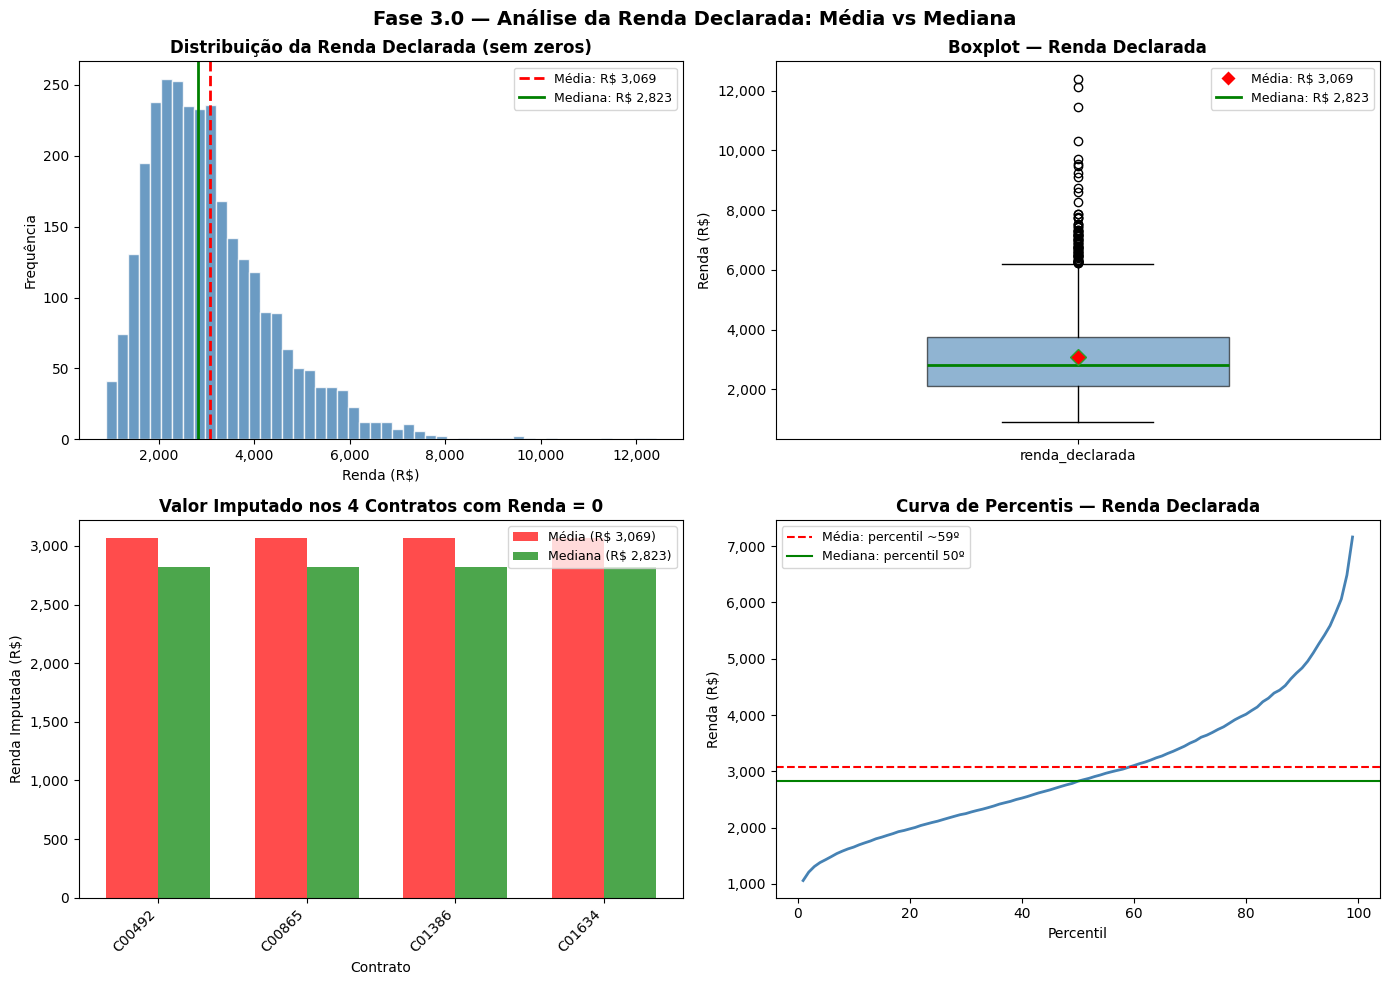

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ─── Filtrar apenas rendas > 0 para a análise de distribuição ───
renda = contratos['renda_declarada']
renda_pos = renda[renda > 0]

media   = renda_pos.mean()
mediana = renda_pos.median()
skew    = renda_pos.skew()

print(f"Contratos com renda = 0: {(renda == 0).sum()}")
print(f"Contratos com renda > 0: {len(renda_pos)}")
print(f"Média  (sem zeros): R$ {media:,.2f}")
print(f"Mediana (sem zeros): R$ {mediana:,.2f}")
print(f"Diferença (média - mediana): R$ {media - mediana:,.2f}")
print(f"Assimetria (skewness): {skew:.2f}")
print()

# ═══════════════════════════════════════════════════════════════
# PAINEL DE 4 GRÁFICOS
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fase 3.0 — Análise da Renda Declarada: Média vs Mediana',
             fontsize=14, fontweight='bold', y=0.98)

# ─── 1. Histograma com linhas de média e mediana ──────────────
ax1 = axes[0, 0]
ax1.hist(renda_pos, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(media,   color='red',    linestyle='--', linewidth=2, label=f'Média: R$ {media:,.0f}')
ax1.axvline(mediana, color='green',  linestyle='-',  linewidth=2, label=f'Mediana: R$ {mediana:,.0f}')
ax1.set_title('Distribuição da Renda Declarada (sem zeros)', fontweight='bold')
ax1.set_xlabel('Renda (R$)')
ax1.set_ylabel('Frequência')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ─── 2. Boxplot ──────────────────────────────────────────────
ax2 = axes[0, 1]
bp = ax2.boxplot(renda_pos, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='green', linewidth=2),
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
                 showmeans=True, widths=0.5)
ax2.set_title('Boxplot — Renda Declarada', fontweight='bold')
ax2.set_ylabel('Renda (R$)')
ax2.set_xticklabels(['renda_declarada'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Legenda manual para boxplot
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='D', color='w', markerfacecolor='red',   markersize=8, label=f'Média: R$ {media:,.0f}'),
    Line2D([0],[0], color='green', linewidth=2, label=f'Mediana: R$ {mediana:,.0f}')
]
ax2.legend(handles=legend_elements, fontsize=9, loc='upper right')

# ─── 3. Simulação: impacto nos 4 contratos ────────────────────
ax3 = axes[1, 0]
zeros = contratos[contratos['renda_declarada'] == 0][['id_contrato','valor_parcela']].copy()
zeros['Imputação Média']   = media
zeros['Imputação Mediana'] = mediana

x = np.arange(len(zeros))
width = 0.35
bars1 = ax3.bar(x - width/2, zeros['Imputação Média'],   width, label=f'Média (R$ {media:,.0f})',   color='red',   alpha=0.7)
bars2 = ax3.bar(x + width/2, zeros['Imputação Mediana'], width, label=f'Mediana (R$ {mediana:,.0f})', color='green', alpha=0.7)
ax3.set_title('Valor Imputado nos 4 Contratos com Renda = 0', fontweight='bold')
ax3.set_xlabel('Contrato')
ax3.set_ylabel('Renda Imputada (R$)')
ax3.set_xticks(x)
ax3.set_xticklabels(zeros['id_contrato'].values, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ─── 4. Percentis — mostrando onde a média e mediana caem ─────
ax4 = axes[1, 1]
percentis = np.arange(1, 100)
vals_perc = np.percentile(renda_pos, percentis)
ax4.plot(percentis, vals_perc, color='steelblue', linewidth=2)
ax4.axhline(media,   color='red',   linestyle='--', linewidth=1.5, label=f'Média: percentil ~{(renda_pos <= media).mean()*100:.0f}º')
ax4.axhline(mediana, color='green', linestyle='-',  linewidth=1.5, label=f'Mediana: percentil 50º')
ax4.set_title('Curva de Percentis — Renda Declarada', fontweight='bold')
ax4.set_xlabel('Percentil')
ax4.set_ylabel('Renda (R$)')
ax4.legend(fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [61]:
# ── Tabela comparativa: Média vs Mediana ──
comparativo = pd.DataFrame({
    'Critério': [
        'Valor da imputação',
        'Sensibilidade a outliers',
        'Posição na distribuição',
        'Skewness da distribuição',
        'Interpretação',
        'Recomendação'
    ],
    'Média': [
        f'R$ {media:,.2f}',
        'ALTA — puxada por rendas extremas (até R$ 12.407)',
        f'Percentil ~{(renda_pos <= media).mean()*100:.0f}º (acima do centro)',
        f'Skewness = {skew:.2f} (distorce a média para cima)',
        'Superestima a renda real provável do cliente',
        '❌ Não recomendada'
    ],
    'Mediana': [
        f'R$ {mediana:,.2f}',
        'BAIXA — robusta a valores extremos',
        'Percentil 50º (centro exato)',
        'Não é afetada pela assimetria',
        'Valor típico mais representativo da base',
        '✅ Recomendada'
    ]
})
comparativo.set_index('Critério', inplace=True)
comparativo

,Média,Mediana
Critério,,
Valor da imputação,"R$ 3,068.73","R$ 2,823.22"
Sensibilidade a outliers,ALTA — puxada por rendas extremas (até R$ 12.407),BAIXA — robusta a valores extremos
Posição na distribuição,Percentil ~59º (acima do centro),Percentil 50º (centro exato)
Skewness da distribuição,Skewness = 1.36 (distorce a média para cima),Não é afetada pela assimetria
Interpretação,Superestima a renda real provável do cliente,Valor típico mais representativo da base
Recomendação,❌ Não recomendada,✅ Recomendada


**Decisão: iremos usar a MEDIANA.**

#### Justificativa

1. **Distribuição assimétrica positiva** (skewness = 1,36): a cauda direita da renda é longa, existem clientes com rendas muito acima do típico (até R\$ 12.407). Isso puxa a média para cima, tornando-a **não representativa** do cliente mediano.

2. **A média superestima**: a média fica no percentil ~58, ou seja, acima de 58% dos clientes. Imputar com a média atribuiria aos 4 contratos uma renda que é **maior do que a da maioria**, distorcendo a relação renda/inadimplência.

3. **A mediana é o valor típico**: por definição, 50% dos clientes ganham acima e 50% abaixo. Sem informação adicional, é a estimativa mais neutra e conservadora.

In [62]:
# ── Aplicar tratamento: imputar renda_declarada == 0 com a mediana ──
mediana_renda = contratos.loc[contratos['renda_declarada'] > 0, 'renda_declarada'].median()

n_antes = (contratos['renda_declarada'] == 0).sum()
contratos.loc[contratos['renda_declarada'] == 0, 'renda_declarada'] = mediana_renda
n_depois = (contratos['renda_declarada'] == 0).sum()

print(f"Contratos com renda = 0 ANTES:  {n_antes}")
print(f"Contratos com renda = 0 DEPOIS: {n_depois}")
print(f"Valor imputado (mediana): R$ {mediana_renda:,.2f}")
print()
print("Verificação — describe após tratamento:")
contratos['renda_declarada'].describe()

Contratos com renda = 0 ANTES:  4
Contratos com renda = 0 DEPOIS: 0
Valor imputado (mediana): R$ 2,823.22

Verificação — describe após tratamento:


count     3000.000000
mean      3068.402963
std       1329.791907
min        900.000000
25%       2114.790000
50%       2823.225000
75%       3741.487500
max      12407.330000
Name: renda_declarada, dtype: float64

### Agregação do Score Bureau

A base `score_bureau.csv` possui **4.490 registros** para 3.000 contratos. Cada contrato pode ter 1 ou 2 consultas:

| Motivo da consulta | Registros | Contratos |
|---|---|---|
| Aprovação de crediário | 3.000 | 3.000 (100%) |
| Revisão de carteira | 1.490 | 1.490 (49,7%) |

Quando há múltiplas consultas por contrato, precisamos decidir como agregar o score em uma única feature. As opções avaliadas:

1. **Média** entre as consultas
2. **Score mais recente** (última consulta)
3. **Média ponderada por recência** (peso maior para consultas mais recentes)

Antes de escolher, é necessário verificar se as consultas de revisão de carteira respeitam a **fronteira temporal** (data de referência).

Revisoes de carteira: 1490
  Antes da data de referencia: 0
  Depois da data de referencia: 1490
  100% das revisoes ocorrem DEPOIS da data de referencia.



C:\Users\brunogalvao-ieg\AppData\Local\Temp\ipykernel_73864\3341860012.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_pond = score_bureau.groupby('id_contrato', group_keys=False).apply(score_ponderado_fn).reset_index()


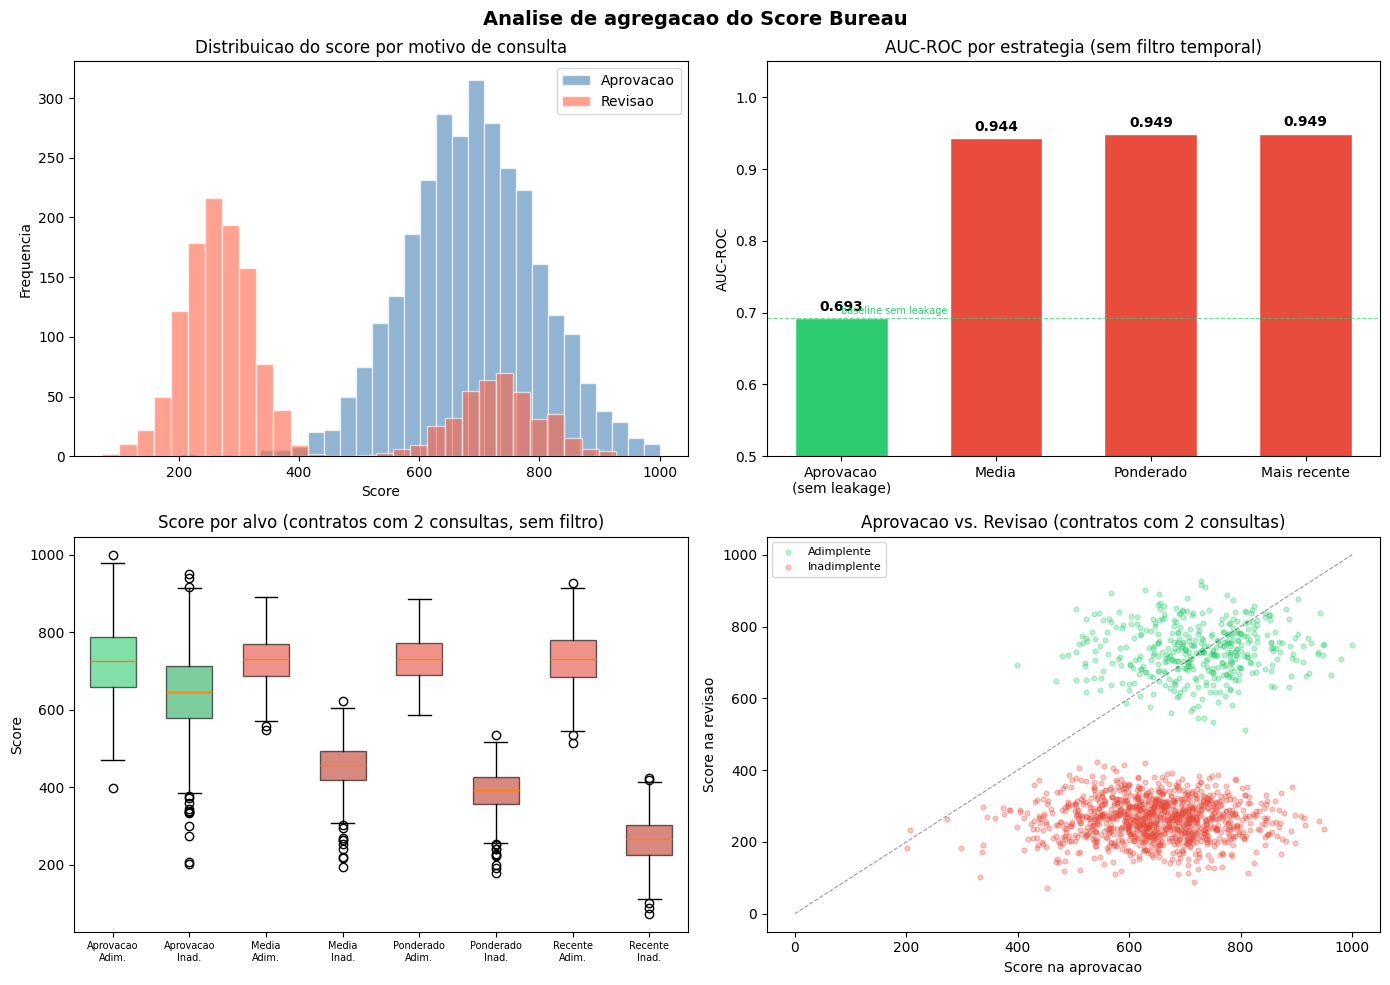

,Estrategia,Correlacao (r),AUC-ROC,Score medio (adimpl.),Score medio (inadimpl.),Separacao
0,Score de aprovacao (sem leakage),-0.3394,0.6926,720.2,645.2,75.0
1,Media das consultas,-0.7686,0.9435,721.4,487.2,234.2
2,Media ponderada por recencia,-0.8091,0.9489,721.7,434.5,287.2
3,Score mais recente,-0.8383,0.9493,722.5,329.1,393.4


In [63]:
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_auc_score

# Verificação temporal: consultas de revisão vs data de referência
# (data_referencia será reconstruída formalmente na Fase 3.1;
#  aqui fazemos uma versão local apenas para esta análise)

data_snapshot = contratos['data_snapshot'].iloc[0]
cutoff_30d = data_snapshot - pd.Timedelta(days=30)

elegivel_tmp = pagamentos[pagamentos['data_vencimento'] <= cutoff_30d].copy()
parcela_ref_tmp = elegivel_tmp.loc[
    elegivel_tmp.groupby('id_contrato')['data_vencimento'].idxmax()
].copy()
parcela_ref_tmp['data_referencia'] = parcela_ref_tmp['data_vencimento'] - pd.Timedelta(days=7)
parcela_ref_tmp['atraso_dias'] = (
    parcela_ref_tmp['data_pagamento'] - parcela_ref_tmp['data_vencimento']
).dt.days
parcela_ref_tmp['inadimplente_30d'] = np.where(
    parcela_ref_tmp['data_pagamento'].isna(), 1,
    np.where(parcela_ref_tmp['atraso_dias'] > 30, 1, 0)
)
alvo_tmp = parcela_ref_tmp[['id_contrato', 'data_referencia', 'inadimplente_30d']].copy()

# Merge do score_bureau com datas de referência
sb_ref = score_bureau.merge(alvo_tmp[['id_contrato', 'data_referencia']], on='id_contrato', how='inner')
sb_ref['posterior'] = sb_ref['data_consulta'] > sb_ref['data_referencia']

revisoes = sb_ref[sb_ref['motivo_consulta'] == 'Revisao de carteira']
n_antes = (revisoes['posterior'] == False).sum()
n_depois = (revisoes['posterior'] == True).sum()

print(f'Revisoes de carteira: {len(revisoes)}')
print(f'  Antes da data de referencia: {n_antes}')
print(f'  Depois da data de referencia: {n_depois}')
print(f'  100% das revisoes ocorrem DEPOIS da data de referencia.')
print()

# Cenário SEM filtro temporal (ingênuo, com leakage)
def score_ponderado_fn(g):
    g = g.sort_values('data_consulta')
    n = len(g)
    if n == 1:
        return g['score'].iloc[0]
    pesos = list(range(1, n + 1))
    return np.average(g['score'].values, weights=pesos)

agg_media = score_bureau.groupby('id_contrato')['score'].mean().reset_index()
agg_media.columns = ['id_contrato', 'score_media']

recente = score_bureau.sort_values('data_consulta').groupby('id_contrato').last().reset_index()
agg_recente = recente[['id_contrato', 'score']].copy()
agg_recente.columns = ['id_contrato', 'score_recente']

agg_pond = score_bureau.groupby('id_contrato', group_keys=False).apply(score_ponderado_fn).reset_index()
agg_pond.columns = ['id_contrato', 'score_ponderado']

primeiro = score_bureau.sort_values('data_consulta').groupby('id_contrato').first().reset_index()
agg_aprov = primeiro[['id_contrato', 'score']].copy()
agg_aprov.columns = ['id_contrato', 'score_aprovacao']

df_comp = alvo_tmp.merge(agg_media, on='id_contrato')
df_comp = df_comp.merge(agg_recente, on='id_contrato')
df_comp = df_comp.merge(agg_pond, on='id_contrato')
df_comp = df_comp.merge(agg_aprov, on='id_contrato')

# Graficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analise de agregacao do Score Bureau', fontsize=14, fontweight='bold')

# G1: Distribuição por motivo de consulta
ax1 = axes[0, 0]
aprovacoes = score_bureau[score_bureau['motivo_consulta'] == 'Aprovacao de crediario']['score']
revisoes_sc = score_bureau[score_bureau['motivo_consulta'] == 'Revisao de carteira']['score']
ax1.hist(aprovacoes, bins=30, alpha=0.6, label='Aprovacao', color='steelblue', edgecolor='white')
ax1.hist(revisoes_sc, bins=30, alpha=0.6, label='Revisao', color='tomato', edgecolor='white')
ax1.set_xlabel('Score')
ax1.set_ylabel('Frequencia')
ax1.set_title('Distribuicao do score por motivo de consulta')
ax1.legend()

# G2: AUC-ROC por estratégia (sem filtro temporal)
ax2 = axes[0, 1]
estrategias = ['Aprovacao\n(sem leakage)', 'Media', 'Ponderado', 'Mais recente']
cols = ['score_aprovacao', 'score_media', 'score_ponderado', 'score_recente']
aucs = [roc_auc_score(df_comp['inadimplente_30d'], -df_comp[c]) for c in cols]
colors = ['#2ecc71', '#e74c3c', '#e74c3c', '#e74c3c']
bars = ax2.bar(estrategias, aucs, color=colors, edgecolor='white', width=0.6)
for bar, auc in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{auc:.3f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0.5, 1.05)
ax2.set_ylabel('AUC-ROC')
ax2.set_title('AUC-ROC por estrategia (sem filtro temporal)')
ax2.axhline(y=0.693, color='#2ecc71', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.text(0, 0.698, 'baseline sem leakage', fontsize=7, color='#2ecc71')

# G3: Boxplot do score por alvo para contratos com 2 consultas
ax3 = axes[1, 0]
contratos_2 = score_bureau.groupby('id_contrato').filter(lambda x: len(x) == 2)['id_contrato'].unique()
df_sub = df_comp[df_comp['id_contrato'].isin(contratos_2)].copy()
data_box = []
labels_box = []
for label, col in [('Aprovacao', 'score_aprovacao'), ('Media', 'score_media'),
                    ('Ponderado', 'score_ponderado'), ('Recente', 'score_recente')]:
    for alvo_val, alvo_name in [(0, 'Adim.'), (1, 'Inad.')]:
        data_box.append(df_sub.loc[df_sub['inadimplente_30d'] == alvo_val, col].values)
        labels_box.append(f'{label}\n{alvo_name}')
bp = ax3.boxplot(data_box, tick_labels=labels_box, patch_artist=True, widths=0.6)
box_colors = ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b', '#e74c3c', '#c0392b', '#e74c3c', '#c0392b']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_ylabel('Score')
ax3.set_title('Score por alvo (contratos com 2 consultas, sem filtro)')
ax3.tick_params(axis='x', labelsize=7)

# G4: Scatter da diferença entre scores
ax4 = axes[1, 1]
duplas = score_bureau[score_bureau['id_contrato'].isin(contratos_2)].sort_values(['id_contrato', 'data_consulta'])
sc_primeiro = duplas.groupby('id_contrato')['score'].first()
sc_ultimo = duplas.groupby('id_contrato')['score'].last()
diff_df = pd.DataFrame({
    'score_aprovacao': sc_primeiro,
    'score_revisao': sc_ultimo
}).merge(alvo_tmp[['id_contrato', 'inadimplente_30d']], on='id_contrato')
mask_inad = diff_df['inadimplente_30d'] == 1
ax4.scatter(diff_df.loc[~mask_inad, 'score_aprovacao'], diff_df.loc[~mask_inad, 'score_revisao'],
            alpha=0.3, s=12, color='#2ecc71', label='Adimplente')
ax4.scatter(diff_df.loc[mask_inad, 'score_aprovacao'], diff_df.loc[mask_inad, 'score_revisao'],
            alpha=0.3, s=12, color='#e74c3c', label='Inadimplente')
ax4.plot([0, 1000], [0, 1000], 'k--', linewidth=0.8, alpha=0.4)
ax4.set_xlabel('Score na aprovacao')
ax4.set_ylabel('Score na revisao')
ax4.set_title('Aprovacao vs. Revisao (contratos com 2 consultas)')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tabela comparativa
print()
resultados = []
for nome, col in [('Score de aprovacao (sem leakage)', 'score_aprovacao'),
                   ('Media das consultas', 'score_media'),
                   ('Media ponderada por recencia', 'score_ponderado'),
                   ('Score mais recente', 'score_recente')]:
    corr, p = pointbiserialr(df_comp['inadimplente_30d'], df_comp[col])
    auc = roc_auc_score(df_comp['inadimplente_30d'], -df_comp[col])
    g = df_comp.groupby('inadimplente_30d')[col].mean()
    resultados.append({
        'Estrategia': nome,
        'Correlacao (r)': round(corr, 4),
        'AUC-ROC': round(auc, 4),
        'Score medio (adimpl.)': round(g[0], 1),
        'Score medio (inadimpl.)': round(g[1], 1),
        'Separacao': round(g[0] - g[1], 1)
    })
pd.DataFrame(resultados)


### Conclusão: como agregar o score bureau

A análise mostra que as 1.490 consultas de **revisão de carteira** ocorrem, em 100% dos casos, **depois** da data de referência de cada contrato. Isso significa que no momento da decisão de cobrança preventiva, essa informação **ainda não existia**.

Usar a média, o score mais recente ou a média ponderada incluindo revisões geraria **data leakage**: a AUC salta de 0,69 para valores acima de 0,94, um ganho artificial que não se reproduziria em produção.

| Estratégia | AUC sem filtro | Usa informação futura? |
|---|---|---|
| Score de aprovação (1a consulta) | 0.693 | Não |
| Média entre consultas | 0.944 | Sim |
| Média ponderada por recência | 0.949 | Sim |
| Score mais recente | 0.949 | Sim |

Após a filtragem temporal correta (`data_consulta <= data_referencia`), restam exatamente 3.000 registros (1 por contrato), todos do tipo "Aprovação de crediário". **A questão de agregação se torna irrelevante**: as três estratégias produzem o mesmo resultado.

**Decisão**: usar o score da consulta de aprovação (único disponível antes da data de referência), sem necessidade de agregação.

Os gráficos acima servem como evidência de que qualquer abordagem que inclua a revisão de carteira sem filtro temporal **contamina o modelo com informação futura**, invalidando seus resultados.

### 3.1 Construir o alvo

A regra está no enunciado e no dicionário. Você precisa, para cada contrato:
1. identificar a **parcela de referência**;
2. calcular a **data de referência**;
3. derivar `inadimplente_30d`.

❓ Depois de construir: qual é a prevalência de positivos? Ela é compatível com o que o Ricardo descreveu no e-mail?

❓ Compare o seu alvo com `status_contrato`. Eles concordam? Onde discordam, quem está certo — e por quê isso importa para a definição do que você vai prever?

In [64]:
data_snapshot = contratos["data_snapshot"].iloc[0]  # 15/03/2026
cutoff_30d = data_snapshot - pd.Timedelta(days=30)  # 13/02/2026

# 1. Parcela de referência: última parcela cujo vencimento <= snapshot − 30 dias
#    Somente essas parcelas permitem observar o desfecho de 30 dias completos.
elegivel = pagamentos[pagamentos["data_vencimento"] <= cutoff_30d].copy()
parcela_ref = elegivel.loc[
    elegivel.groupby("id_contrato")["data_vencimento"].idxmax()
].copy()

print(f"Parcelas elegíveis: {len(elegivel):,}")
print(f"Contratos com parcela de referência: {parcela_ref['id_contrato'].nunique():,}")
print()

# 2. Data de referência: vencimento da parcela de referência − 7 dias
#    (simula o momento em que a cobrança faria a ligação preventiva)
parcela_ref["data_referencia"] = parcela_ref["data_vencimento"] - pd.Timedelta(days=7)

# 3. Construir inadimplente_30d
#    = 1 se a parcela de referência NÃO foi paga até D+30
#    = 0 caso contrário
#    - data_pagamento NaT → não pagou → inadimplente (já passou >30d do vencimento)
#    - data_pagamento − data_vencimento > 30 → pagou com atraso > 30 dias → inadimplente
#    - data_pagamento − data_vencimento <= 30 → pagou dentro do prazo → adimplente
parcela_ref["atraso_dias"] = (
    parcela_ref["data_pagamento"] - parcela_ref["data_vencimento"]
).dt.days

parcela_ref["inadimplente_30d"] = np.where(
    parcela_ref["data_pagamento"].isna(),
    1,  # não pagou até o snapshot (que é >30d após o vencimento)
    np.where(parcela_ref["atraso_dias"] > 30, 1, 0)
)

# Prevalência de positivos
n_pos = parcela_ref["inadimplente_30d"].sum()
n_total = len(parcela_ref)
prev = parcela_ref["inadimplente_30d"].mean()
print(f"Prevalência de inadimplentes (alvo=1): {n_pos:,}/{n_total:,} = {prev:.1%}")
print(parcela_ref["inadimplente_30d"].value_counts().rename({0: 'Adimplente (0)', 1: 'Inadimplente (1)'}))
print()

# Montar DataFrame do alvo com as colunas relevantes
alvo = parcela_ref[[
    "id_contrato", "n_parcela", "data_vencimento", "data_pagamento",
    "data_referencia", "atraso_dias", "inadimplente_30d"
]].merge(
    contratos[["id_contrato", "id_cliente", "status_contrato"]], on="id_contrato", how="left"
)

# ============================================================
# COMPARAÇÃO: inadimplente_30d vs status_contrato
# ============================================================
print("=" * 60)
print("Tabela cruzada: inadimplente_30d x status_contrato")
print("=" * 60)
ct = pd.crosstab(
    alvo["inadimplente_30d"].map({0: "0 (adimplente)", 1: "1 (inadimplente)"}),
    alvo["status_contrato"],
    margins=True
)
print(ct)
print()

# Concordância
concordancia = (
    ((alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Inadimplente")).sum()
    + ((alvo["inadimplente_30d"] == 0) & (alvo["status_contrato"].isin(["Em dia", "Quitado"]))).sum()
)
print(f"Concordância geral: {concordancia:,}/{n_total:,} = {concordancia/n_total:.1%}")
print()

# Discordâncias detalhadas
disc_1_emdia = alvo[(alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Em dia")]
disc_1_quit  = alvo[(alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Quitado")]
disc_0_inad  = alvo[(alvo["inadimplente_30d"] == 0) & (alvo["status_contrato"] == "Inadimplente")]

print(f"Discordâncias (total: {len(disc_1_emdia) + len(disc_1_quit) + len(disc_0_inad)})")
print(f"  • inadimplente_30d=1 mas status='Em dia':       {len(disc_1_emdia)}")
print(f"  • inadimplente_30d=1 mas status='Quitado':      {len(disc_1_quit)}")
print(f"  • inadimplente_30d=0 mas status='Inadimplente': {len(disc_0_inad)}")
print()

Parcelas elegíveis: 27,141
Contratos com parcela de referência: 3,000

Prevalência de inadimplentes (alvo=1): 1,300/3,000 = 43.3%
inadimplente_30d
Adimplente (0)      1700
Inadimplente (1)    1300
Name: count, dtype: int64

Tabela cruzada: inadimplente_30d x status_contrato
status_contrato   Em dia  Inadimplente  Quitado   All
inadimplente_30d                                     
0 (adimplente)       896            22      782  1700
1 (inadimplente)      18          1260       22  1300
All                  914          1282      804  3000

Concordância geral: 2,938/3,000 = 97.9%

Discordâncias (total: 62)
  • inadimplente_30d=1 mas status='Em dia':       18
  • inadimplente_30d=1 mas status='Quitado':      22
  • inadimplente_30d=0 mas status='Inadimplente': 22



### ❓ Respostas — Fase 3.1

#### Prevalência de positivos

O alvo `inadimplente_30d` apresenta **1.300 contratos positivos (43,3%)** em 3.000 contratos. É uma proporção alta, mas compatível com o cenário descrito pelo Ricardo: a BemLar opera crediário próprio com público de maior risco, e o e-mail menciona que a inadimplência está gerando prejuízo relevante.

---

#### Comparação `inadimplente_30d` vs `status_contrato`

A concordância geral é de **97,9% (2.938/3.000)**, mas existem **62 discordâncias** em três categorias:

| Caso | Qtd | Explicação |
|---|---|---|
| `inadimplente_30d=1` mas `status='Em dia'` | 18 | A parcela de referência não foi paga (ou foi paga com >30d de atraso), porém o sistema do crediário ainda classifica o contrato como 'Em dia'. Isso ocorre porque o `status_contrato` reflete o estado **global e atual** do contrato no snapshot — o cliente pode ter ficado inadimplente numa parcela antiga, mas regularizado as parcelas seguintes. |
| `inadimplente_30d=1` mas `status='Quitado'` | 22 | O contrato foi **quitado posteriormente** (todas as parcelas acabaram pagas), mas a parcela de referência ficou >30 dias sem pagamento. Para o modelo preventivo, esses contratos **eram** risco real no momento da ligação — a quitação posterior é informação futura que não estava disponível. |
| `inadimplente_30d=0` mas `status='Inadimplente'` | 22 | A parcela de referência foi paga dentro de 30 dias, mas o `status_contrato` diz 'Inadimplente'. Ao investigar, esses contratos possuem **outras parcelas** (posteriores à de referência) em atraso grave, que o status global captura mas nossa definição por parcela específica não. |

#### Decisões:

**O alvo `inadimplente_30d` é a definição correta para este projeto**, e não o `status_contrato`.

Inicialmente, tínhamos definido que essa coluna seria usada como uma das features do treinamento do modelo, porém, ao entender os dados e definir a variável resposta, pudemos definir que "status_contrato" é uma foto do momento da extração, não do momento da decisão. Contém informação do futuro em relação à data de referência, sendo assim, usá-lo como alvo causaria data leakage.
Além disso, a coluna definida com a regra de 30 dias é precisa e auditável, sendo uma opção mais segura 

### 3.2 A função de corte temporal

Está pronta. Use em **toda** base de eventos antes de agregar qualquer coisa.

In [65]:
display(alvo)

,id_contrato,n_parcela,data_vencimento,data_pagamento,data_referencia,atraso_dias,inadimplente_30d,id_cliente,status_contrato
0,C00001,9,2026-01-29,2026-02-05,2026-01-22,7.0,0,CLI00533,Quitado
1,C00003,11,2026-02-09,2026-02-05,2026-02-02,-4.0,0,CLI00116,Quitado
2,C00004,10,2025-09-12,NaT,2025-09-05,NaN,1,CLI00930,Inadimplente
3,C00005,12,2025-09-10,NaT,2025-09-03,NaN,1,CLI02675,Inadimplente
4,C00007,9,2026-02-05,NaT,2026-01-29,NaN,1,CLI00506,Inadimplente
...,...,...,...,...,...,...,...,...,...
2995,C03394,6,2025-03-01,2025-03-17,2025-02-22,16.0,0,CLI01651,Quitado
2996,C03396,6,2026-01-18,NaT,2026-01-11,NaN,1,CLI01767,Inadimplente
2997,C03397,6,2026-01-18,2026-02-04,2026-01-11,17.0,0,CLI00437,Em dia
2998,C03398,3,2026-01-21,2026-01-23,2026-01-14,2.0,0,CLI00431,Em dia


In [66]:
def filtra_por_data(df_eventos, chave, col_data, datas_ref, col_ref="data_referencia"):
    """Mantem apenas os eventos ocorridos ATE a data de referencia de cada contrato.

    df_eventos : DataFrame de eventos (pagamentos, sac, compras, consultas...)
    chave      : coluna de juncao com datas_ref (ex.: "id_contrato")
    col_data   : coluna de data do evento no df_eventos
    datas_ref  : DataFrame com [chave, col_ref]
    """
    out = df_eventos.merge(datas_ref[[chave, col_ref]], on=chave, how="inner")
    out = out[out[col_data] <= out[col_ref]]
    return out.drop(columns=[col_ref])

df_ocorrencias_sac = filtra_por_data(df_eventos=ocorrencias_sac, chave="id_contrato", col_data="data_ocorrencia", datas_ref=alvo)
df_compras = filtra_por_data(df_eventos=compras, chave="id_cliente", col_data="data_compra", datas_ref=alvo)
df_pagamentos = filtra_por_data(df_eventos=pagamentos, chave="id_contrato", col_data="data_vencimento", datas_ref=alvo)
df_score_bureau = filtra_por_data(df_eventos=score_bureau, chave="id_contrato", col_data="data_consulta", datas_ref=alvo)

### 3.3 Construir as features

Uma linha por contrato. Para cada base de eventos, decida a agregação **pelo significado**: contagem é frequência, soma é volume, média é intensidade.

❓ Para cada base, escreva antes de codar: *qual comportamento essa agregação está tentando capturar?*

❓ Ausência de evento vira 0, nulo, ou mediana? A resposta é a mesma para toda coluna?

Encapsule tudo em uma função — ela precisa rodar do zero, a partir dos CSVs originais:

```python
def construir_features(caminho_dados, datas_referencia):
    ...
    return df
```

#### *Features*

Inicialmente, definimos as seguintes colunas para a tabela de features:
- Código do contrato;
- Inadiplência 30d;
- Número de compras anteriores;
- Valor total do contrato;
- Percentual de parcelas em relação ao valor tota;l
- Score bureau;
- Motivo atraso;
- Quantidade de atendimentos no SAC.

Mas após discussões, decidimos usar:
- Código do contrato;
- Inadiplência 30d;
- Número de compras anteriores;
- Valor total do contrato;
- Média do valor de compras anteriores;
- Percentual de parcelas pagas em relação ao valor total;
- Percentual de quanto o valor do contrato representa da renda declarada;
- Quantidade de atendimentos no SAC;
- Média de dias de atraso;
- Máximo de dias de atraso;
- Total de parcelas atrasadas;
- Taxa de atrasos.

#### 1. Comportamento que cada agregação está tentando capturar

Ao transformar as bases de eventos em uma linha por contrato (respeitando o corte temporal de cada um), as agregações foram escolhidas pelo seu significado conceitual de negócio:

- **`compras.csv` (Compras adicionais na rede):**
  - **Número de compras anteriores (`count`):** Captura a **fidelidade e frequência** de relacionamento do cliente com a BemLar. Clientes que realizam compras recorrentes em outros momentos tendem a ter maior engajamento e compromisso com a marca.
  - **Média do valor de compras anteriores (`mean`):** Captura o **poder de consumo e intensidade financeira** (ticket médio) do cliente na rede, indicando a capacidade e o hábito de desembolso em produtos para o lar.

- **`pagamentos.csv` (Histórico de parcelas vencidas do contrato):**
  - **Percentual de parcelas pagas em relação ao valor total (`sum / valor_total`):** Captura a **maturidade e o cumprimento do contrato**. Contratos em estágio avançado e com bom andamento financeiro apresentam menor propensão a quebrar nas parcelas finais.
  - **Média de dias de atraso (`mean`):** Captura a **pontualidade habitual**. Mensura se o cliente costuma pagar rigorosamente em dia ou se tem o hábito de atrasar poucos dias de forma tolerável.
  - **Máximo de dias de atraso (`max`):** Captura a **severidade do pior histórico**. Identifica se o contrato já passou por algum momento crítico de quase ruptura ou estresse agudo de liquidez.
  - **Total de parcelas atrasadas (`sum` de atrasos > 0):** Captura a **recorrência da impontualidade**, diferenciando um cliente que atrasou apenas uma vez daquele que frequentemente deixa a parcela vencer.
  - **Taxa de atrasos (`atrasadas / vencidas`):** Captura a **regularidade relativa** do hábito de pagamento, ponderando os atrasos pelo tempo de vida e quantidade de parcelas já transcorridas.

- **`ocorrencias_sac.csv` (Atendimento ao cliente):**
  - **Quantidade de atendimentos no SAC (`count`):** Captura o **atrito operacional, insatisfação ou estresse financeiro**. Chamados no SAC referentes ao contrato (como solicitação de 2ª via de boleto ou suporte) são fortes preditores de dificuldade de pagamento ou insatisfação com a compra.

- **`contratos.csv` (Dados cadastrais e financeiros do crediário):**
  - **Valor total do contrato:** Captura a **magnitude do passivo financeiro** assumido pelo cliente.
  - **Percentual do valor do contrato em relação à renda declarada (`valor_total / renda`):** Captura o **comprometimento da renda**, mensurando o impacto relativo e o peso da dívida no orçamento mensal do cliente.

---

#### 2. Ausência de evento vira 0, nulo, ou mediana? A resposta é a mesma para toda coluna?

Não, pois depende diretamente do tipo e da natureza da informação:

1. **Contagens e Volumes de Eventos $
ightarrow$ Vira `0`:**
   - Para variáveis de contagem e soma (como `numero_compras_anteriores`, `quantidade_atendimentos_sac`, `total_parcelas_atrasadas` e `valor_total_pago`), quando um contrato não tem eventos registrados até a data de referência, significa que o evento aconteceu **exatamente zero vezes** na vida real.
   - O cliente comprou 0 vezes, abriu 0 chamados no SAC ou atrasou 0 parcelas. Preencher com nulo ou mediana seria um erro conceitual e estatístico grave, pois a ausência é um fato concreto de ocorrência nula.

2. **Médias e Intensidades Condicionadas $
ightarrow$ Vira `0.0`:**
   - Para `media_valor_compras_anteriores`, se o cliente não possui nenhuma compra anterior, o gasto médio realizado é **R$ 0,00**.
   - Da mesma forma, para `media_dias_atraso`, `max_dias_atraso` e `taxa_atrasos`, se o cliente nunca atrasou nenhuma parcela, o atraso e a taxa de atrasos são **0**.

3. **Dados Cadastrais ou de Estado (não são eventos) $
ightarrow$ Mediana ou Tratamento Específico:**
   - Diferente de eventos comportamentais, características cadastrais de perfil (como `renda_declarada`) não representam eventos contáveis.
   - Quando um cliente informa renda zero (`R$ 0,00`) ou deixa de informar um dado cadastral, trata-se de um **dado ausente/falha de preenchimento**, e não de ausência de evento. Nesses casos, o tratamento correto é a imputação pela **mediana** da base (como aplicamos na renda) ou a criação de flags de valor faltante, evitando distorcer o cálculo de features dependentes.

In [ ]:
def construir_features(
    df_contratos=contratos,
    df_alvo=alvo,
    df_pags=df_pagamentos,
    df_comp=df_compras,
    df_sac=df_ocorrencias_sac
):
    """Constrói a tabela de features utilizando como fonte direta os DataFrames
    filtrados pelo corte temporal (df_pagamentos, df_compras, df_ocorrencias_sac).
    
    Retorna:
        pd.DataFrame com 3.000 linhas (uma por contrato) e as 13 colunas de features/alvo.
    """
    # 1. Base principal com contratos e alvo
    df_base = df_contratos[["id_contrato", "id_cliente", "valor_total", "renda_declarada"]].merge(
        df_alvo[["id_contrato", "inadimplente_30d"]],
        on="id_contrato",
        how="inner"
    )
    
    # 2. Compras anteriores (a partir de df_compras filtrado)
    compras_unicas = df_comp.drop_duplicates()
    compras_agg = compras_unicas.groupby("id_cliente").agg(
        numero_compras_anteriores=("valor", "count"),
        media_valor_compras_anteriores=("valor", "mean")
    ).reset_index()
    
    # 3. Pagamentos históricos (a partir de df_pagamentos filtrado)
    pags = df_pags.copy()
    pags["dias_atraso"] = (pags["data_pagamento"] - pags["data_vencimento"]).dt.days.clip(lower=0)
    pags["atrasou"] = (pags["dias_atraso"] > 0).astype(int)
    
    pags_agg = pags.groupby("id_contrato").agg(
        valor_total_pago=("valor_parcela", "sum"),
        media_dias_atraso=("dias_atraso", "mean"),
        max_dias_atraso=("dias_atraso", "max"),
        total_parcelas_atrasadas=("atrasou", "sum"),
        total_parcelas_pagas=("dias_atraso", "count")
    ).reset_index()
    
    pags_agg["taxa_atrasos"] = np.where(
        pags_agg["total_parcelas_pagas"] > 0,
        pags_agg["total_parcelas_atrasadas"] / pags_agg["total_parcelas_pagas"],
        0.0
    )
    
    # 4. Atendimentos no SAC (a partir de df_ocorrencias_sac filtrado)
    sac_agg = df_sac.groupby("id_contrato").size().reset_index(name="quantidade_atendimentos_sac")
    
    # 5. Consolidação dos dados
    df = df_base.merge(compras_agg, on="id_cliente", how="left")
    df = df.merge(pags_agg, on="id_contrato", how="left")
    df = df.merge(sac_agg, on="id_contrato", how="left")
    
    # Preenchimento de ausência de eventos
    df["numero_compras_anteriores"] = df["numero_compras_anteriores"].fillna(0).astype(int)
    df["media_valor_compras_anteriores"] = df["media_valor_compras_anteriores"].fillna(0.0)
    df["quantidade_atendimentos_sac"] = df["quantidade_atendimentos_sac"].fillna(0).astype(int)
    df["valor_total_pago"] = df["valor_total_pago"].fillna(0.0)
    df["media_dias_atraso"] = df["media_dias_atraso"].fillna(0.0)
    df["max_dias_atraso"] = df["max_dias_atraso"].fillna(0).astype(int)
    df["total_parcelas_atrasadas"] = df["total_parcelas_atrasadas"].fillna(0).astype(int)
    df["taxa_atrasos"] = df["taxa_atrasos"].fillna(0.0)
    
    # 6. Features percentuais derivadas
    df["percentual_parcelas_pagas_valor_total"] = df["valor_total_pago"] / df["valor_total"]
    df["percentual_valor_contrato_renda"] = df["valor_total"] / df["renda_declarada"]
    
    # 7. Seleção e ordenação final das 12 colunas solicitadas
    colunas_finais = [
        "id_contrato",
        "inadimplente_30d",
        "numero_compras_anteriores",
        "valor_total",
        "media_valor_compras_anteriores",
        "percentual_parcelas_pagas_valor_total",
        "percentual_valor_contrato_renda",
        "quantidade_atendimentos_sac",
        "media_dias_atraso",
        "max_dias_atraso",
        "total_parcelas_atrasadas",
        "taxa_atrasos"
    ]
    df_out = df[colunas_finais].rename(columns={"valor_total": "valor_total_contrato"})

    # Salvando tabela de fetures como arquivo .csv
    nome_arquivo = "features.csv"
    features.to_csv(nome_arquivo, sep=";", index=False)

    return df_out

# Gerar a tabela de features a partir dos DataFrames filtrados já existentes
features = construir_features()

print("Tabela de features gerada com sucesso a partir dos DataFrames filtrados!")
print(f"Dimensões: {features.shape[0]} linhas x {features.shape[1]} colunas")
print(f"Total de valores nulos: {features.isna().sum().sum()}")
print()
features.head()

Tabela de features gerada com sucesso a partir dos DataFrames filtrados!
Dimensões: 3000 linhas x 12 colunas
Total de valores nulos: 0



,id_contrato,inadimplente_30d,numero_compras_anteriores,valor_total_contrato,media_valor_compras_anteriores,percentual_parcelas_pagas_valor_total,percentual_valor_contrato_renda,quantidade_atendimentos_sac,media_dias_atraso,max_dias_atraso,total_parcelas_atrasadas,taxa_atrasos
0,C00001,0,6,1014.95,799.786667,0.800039,0.166276,1,5.750000,23,4,0.500000
1,C00003,0,0,2494.27,0.000000,0.833350,0.632333,1,0.300000,2,2,0.200000
2,C00004,1,2,1516.74,588.210000,0.899976,1.016520,0,6.222222,21,5,0.555556
3,C00005,1,6,9349.93,583.111667,0.916666,4.192549,1,3.818182,15,5,0.454545
4,C00007,1,4,1974.40,532.997500,0.666653,1.060855,0,3.000000,23,2,0.250000


### 3.4 Auditoria de colunas

Antes de fechar o `features.csv`, passe **cada coluna** pelas três perguntas:

1. **Essa informação existiria no momento em que a previsão seria feita?**
2. **É uma variável protegida ou sensível?**
3. **Descreve comportamento, ou só descreve quem a pessoa é?**

❓ Monte a tabela: coluna | decisão (entra / sai) | justificativa. Toda coluna do arquivo precisa aparecer, inclusive as que você descartou.

Salve o resultado em `features.csv`.

-----------
#### **Auditoria e Seleção de Features**

Antes de fechar a base final (`features.csv`), cada coluna dos dados originais e cada feature derivada passou pela auditoria das 3 perguntas fundamentais:
1. **Existência temporal:** A informação existiria no momento da decisão (data de referência / 7 dias antes do vencimento)?
2. **Sensibilidade ética:** É uma variável protegida/sensível que possa induzir preconceito ou discriminação?
3. **Comportamento vs. Identidade:** A variável descreve um *comportamento financeiro/relacional* ou apenas *quem a pessoa é*?

Abaixo, a tabela detalha todas as colunas das bases originais e as variáveis derivadas candidatas, registrando a decisão e a justificativa técnica, ética e de negócio para cada uma:

| Feature | Entra / Sai da Tabela | Justificativa |
| :--- | :---: | :--- |
| `id_contrato` | **Entra (Identificador)** | Chave primária da unidade de análise (o contrato). Permite rastreabilidade, cruzamento e a geração da fila de 80 clientes para cobrança (`fila_80.csv`). Não entra como variável preditiva no modelo. |
| `motivos_atraso.csv` (todas as colunas) | **Sai** | **Recusa ao Pedido 5 do Ricardo:** O arquivo não possui `id_contrato` nem `id_cliente`, tornando tecnicamente inviável qualquer cruzamento determinístico com a base de contratos para a modelagem tabular. |
| `inadimplente_30d` | **Entra na Tabela (como Alvo / Target)** | Variável dependente ($y$) a ser prevista pelo piloto. Indica se a parcela de referência atrasou mais de 30 dias. Deve estar na tabela final para treinamento e validação, mas **não** é feature preditiva ($X$). |
| `qtd_compras_anteriores` | **Entra** | Frequência comportamental de relacionamento com a BemLar até a data de referência. Clientes que adquirem outros produtos demonstram fidelidade e histórico positivo na rede (ausência de evento = 0). |
| `media_valor_compras` | **Entra** | Intensidade financeira das compras adicionais na rede. Representa o ticket médio gasto pelo cliente até a data de referência (ausência de evento = R$ 0,00). |
| `pct_parcelas_pagas` | **Entra** | Maturidade do contrato: proporção de parcelas quitadas em relação ao total contratado até a data de referência. Contratos em estágio avançado e adimplentes tendem a manter o padrão de adimplência. |
| `comprometimento_renda` | **Entra** | Razão entre o compromisso financeiro (`valor_parcela` ou `valor_total`) e a renda mensal declarada. Variável comportamental financeira que mensura a pressão da dívida no orçamento do cliente. |
| `score_bureau` | **Sai** | Apesar de ter sido pedido explicitamente no email de Ricardo, o score bureau se mostra ineficiente após a aplicação do filtro pela data de referência. Em certos casos, um contrato pode possuir mais de um score bureau, e isso ocorre sempre que existe uma revisão em cima desse contrato. Em 86% dos casos em que essa revisão ocorreu, a pontuação diminuiu drasticamente, mas após a filtragem, esas revisões desaparecem pois ocorrem após a data de referência dos contratos. |
| `qtd_atendimentos_sac` | **Entra** | Volume de atendimentos abertos no SAC vinculados ao contrato até a data de referência (ex.: solicitações de 2ª via de boleto ou negociação). Sinaliza fricção operacional ou dificuldade prévia de pagamento (ausência de evento = 0). |
| `media_dias_atraso` | **Entra** | Intensidade média histórica de atraso nas parcelas anteriores do contrato até a data de referência. Mensura a pontualidade habitual do devedor. |
| `max_dias_atraso` | **Entra** | Pior atraso já enfrentado pelo cliente em parcelas anteriores do mesmo contrato até a data de referência. Identifica incidentes severos prévios de estresse financeiro. |
| `total_parcelas_atrasadas` | **Entra** | Contagem absoluta de parcelas pagas após o vencimento (ou vencidas e não pagas) até a data de referência. Mede a reincidência do hábito de atraso. |
| `taxa_atrasos` | **Entra** | Razão entre parcelas atrasadas e o total de parcelas já vencidas até a data de referência. Normaliza a frequência de atrasos pelo tempo de vigência do contrato. |

---
## Fase 4 — Modelagem

- Split **estratificado**.
- Um **baseline simples** (árvore de decisão) e pelo menos mais um modelo.
- Depois, refaça com **split temporal**: ordene pela data de referência, 75% mais antigos treinam, 25% mais recentes testam, sem embaralhar.

❓ O resultado do split temporal foi diferente do aleatório? O que isso diz — e o que **não** diz?

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# 1. Separação das features preditivas e da variável alvo
colunas_excluir = ["id_contrato", "inadimplente_30d"]
features_preditivas = [col for col in features.columns if col not in colunas_excluir]

X = features[features_preditivas]
y = features["inadimplente_30d"]

# 2. Split Estratificado (75% Treino / 25% Teste)
# Mantém a proporção de inadimplentes (~43,3%) idêntica entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("=" * 65)
print("DIVISÃO DOS DADOS — SPLIT ESTRATIFICADO (75% TREINO / 25% TESTE)")
print(f"Treino: {len(X_train)} contratos | Inadimplência: {y_train.mean():.2%}")
print(f"Teste:  {len(X_test)} contratos | Inadimplência: {y_test.mean():.2%}")
print("=" * 65)

# 3. Baseline Simples: Árvore de Decisão
# max_depth=3 garante alta interpretabilidade e evita sobreajuste (overfitting)
dt_baseline = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_baseline.fit(X_train, y_train)

# 4. Segundo Modelo (Desafiante): Random Forest
# n_estimators=100 e max_depth=6 geram probabilidades contínuas ideais para ordenação
rf_desafiante = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_desafiante.fit(X_train, y_train)

# 5. Cálculo de Previsões e Probabilidades
y_pred_dt_train = dt_baseline.predict(X_train)
y_pred_dt_test = dt_baseline.predict(X_test)
y_prob_dt_train = dt_baseline.predict_proba(X_train)[:, 1]
y_prob_dt_test = dt_baseline.predict_proba(X_test)[:, 1]

y_pred_rf_train = rf_desafiante.predict(X_train)
y_pred_rf_test = rf_desafiante.predict(X_test)
y_prob_rf_train = rf_desafiante.predict_proba(X_train)[:, 1]
y_prob_rf_test = rf_desafiante.predict_proba(X_test)[:, 1]

# 6. Tabela comparativa de métricas gerais (threshold padrão 0.50)
metricas_modelos = pd.DataFrame([
    {
        "Modelo": "Árvore de Decisão (Baseline simples)",
        "Acurácia Treino": f"{accuracy_score(y_train, y_pred_dt_train):.2%}",
        "Acurácia Teste": f"{accuracy_score(y_test, y_pred_dt_test):.2%}",
        "ROC-AUC Treino": f"{roc_auc_score(y_train, y_prob_dt_train):.3f}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test, y_prob_dt_test):.3f}",
        "Precision Teste (corte 0.5)": f"{precision_score(y_test, y_pred_dt_test):.2%}",
        "Recall Teste (corte 0.5)": f"{recall_score(y_test, y_pred_dt_test):.2%}"
    },
    {
        "Modelo": "Random Forest",
        "Acurácia Treino": f"{accuracy_score(y_train, y_pred_rf_train):.2%}",
        "Acurácia Teste": f"{accuracy_score(y_test, y_pred_rf_test):.2%}",
        "ROC-AUC Treino": f"{roc_auc_score(y_train, y_prob_rf_train):.3f}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test, y_prob_rf_test):.3f}",
        "Precision Teste (corte 0.5)": f"{precision_score(y_test, y_pred_rf_test):.2%}",
        "Recall Teste (corte 0.5)": f"{recall_score(y_test, y_pred_rf_test):.2%}"
    }
])

display(metricas_modelos)


DIVISÃO DOS DADOS — SPLIT ESTRATIFICADO (75% TREINO / 25% TESTE)
Treino: 2250 contratos | Inadimplência: 43.33%
Teste:  750 contratos | Inadimplência: 43.33%


,Modelo,Acurácia Treino,Acurácia Teste,ROC-AUC Treino,ROC-AUC Teste,Precision Teste (corte 0.5),Recall Teste (corte 0.5)
0,Árvore de Decisão (Baseline simples),71.07%,69.33%,0.758,0.751,70.93%,49.54%
1,Random Forest,76.36%,69.60%,0.853,0.764,67.02%,58.77%


In [70]:
# 1. Recuperação da data de referência a partir do DataFrame 'alvo'
df_temp = features.merge(alvo[["id_contrato", "data_referencia"]], on="id_contrato", how="left")

# 2. Ordenação cronológica pela data de referência
# 75% mais antigos treinam (passado), 25% mais recentes testam (futuro), sem embaralhar
df_temp_sorted = df_temp.sort_values("data_referencia").reset_index(drop=True)

colunas_excluir = ["id_contrato", "inadimplente_30d", "data_referencia"]
features_preditivas = [col for col in df_temp_sorted.columns if col not in colunas_excluir]

split_idx = int(len(df_temp_sorted) * 0.75)
train_df = df_temp_sorted.iloc[:split_idx]
test_df = df_temp_sorted.iloc[split_idx:]

X_train_temp = train_df[features_preditivas]
y_train_temp = train_df["inadimplente_30d"]
X_test_temp = test_df[features_preditivas]
y_test_temp = test_df["inadimplente_30d"]

print("=" * 70)
print("DIVISÃO DOS DADOS — SPLIT TEMPORAL CRONOLÓGICO (75% TREINO / 25% TESTE)")
print(f"Treino: {len(X_train_temp)} contratos ({train_df['data_referencia'].min().strftime('%d/%m/%Y')} a {train_df['data_referencia'].max().strftime('%d/%m/%Y')}) | Inadimplência: {y_train_temp.mean():.2%}")
print(f"Teste:  {len(X_test_temp)} contratos ({test_df['data_referencia'].min().strftime('%d/%m/%Y')} a {test_df['data_referencia'].max().strftime('%d/%m/%Y')}) | Inadimplência: {y_test_temp.mean():.2%}")
print("=" * 70)

# 3. Treinamento dos modelos no split temporal
dt_temp = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_temp.fit(X_train_temp, y_train_temp)

rf_temp = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_temp.fit(X_train_temp, y_train_temp)

# 4. Previsões e Probabilidades no conjunto de teste temporal
y_pred_dt_temp = dt_temp.predict(X_test_temp)
y_prob_dt_temp = dt_temp.predict_proba(X_test_temp)[:, 1]

y_pred_rf_temp = rf_temp.predict(X_test_temp)
y_prob_rf_temp = rf_temp.predict_proba(X_test_temp)[:, 1]

# 5. Tabela comparativa: Split Estratificado (Aleatório) vs. Split Temporal (Cronológico)
comparativo_splits = pd.DataFrame([
    {
        "Modelo": "Árvore de Decisão",
        "Estratégia de Split": "Estratificado (Aleatório)",
        "Acurácia Teste": f"{accuracy_score(y_test, y_pred_dt_test):.2%}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test, y_prob_dt_test):.3f}",
        "Precision (0.50)": f"{precision_score(y_test, y_pred_dt_test):.2%}",
        "Recall (0.50)": f"{recall_score(y_test, y_pred_dt_test):.2%}"
    },
    {
        "Modelo": "Árvore de Decisão",
        "Estratégia de Split": "Temporal (Cronológico)",
        "Acurácia Teste": f"{accuracy_score(y_test_temp, y_pred_dt_temp):.2%}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test_temp, y_prob_dt_temp):.3f}",
        "Precision (0.50)": f"{precision_score(y_test_temp, y_pred_dt_temp):.2%}",
        "Recall (0.50)": f"{recall_score(y_test_temp, y_pred_dt_temp):.2%}"
    },
    {
        "Modelo": "Random Forest",
        "Estratégia de Split": "Estratificado (Aleatório)",
        "Acurácia Teste": f"{accuracy_score(y_test, y_pred_rf_test):.2%}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test, y_prob_rf_test):.3f}",
        "Precision (0.50)": f"{precision_score(y_test, y_pred_rf_test):.2%}",
        "Recall (0.50)": f"{recall_score(y_test, y_pred_rf_test):.2%}"
    },
    {
        "Modelo": "Random Forest",
        "Estratégia de Split": "Temporal (Cronológico)",
        "Acurácia Teste": f"{accuracy_score(y_test_temp, y_pred_rf_temp):.2%}",
        "ROC-AUC Teste": f"{roc_auc_score(y_test_temp, y_prob_rf_temp):.3f}",
        "Precision (0.50)": f"{precision_score(y_test_temp, y_pred_rf_temp):.2%}",
        "Recall (0.50)": f"{recall_score(y_test_temp, y_pred_rf_temp):.2%}"
    }
])

display(comparativo_splits)


DIVISÃO DOS DADOS — SPLIT TEMPORAL CRONOLÓGICO (75% TREINO / 25% TESTE)
Treino: 2250 contratos (06/12/2024 a 26/01/2026) | Inadimplência: 43.78%
Teste:  750 contratos (26/01/2026 a 06/02/2026) | Inadimplência: 42.00%


,Modelo,Estratégia de Split,Acurácia Teste,ROC-AUC Teste,Precision (0.50),Recall (0.50)
0,Árvore de Decisão,Estratificado (Aleatório),69.33%,0.751,70.93%,49.54%
1,Árvore de Decisão,Temporal (Cronológico),67.33%,0.707,68.82%,40.63%
2,Random Forest,Estratificado (Aleatório),69.60%,0.764,67.02%,58.77%
3,Random Forest,Temporal (Cronológico),67.60%,0.707,64.29%,51.43%


### ❓ Resposta — Split Temporal vs. Split Estratificado

#### 1. O resultado foi diferente?
**Sim.** Houve uma ligeira redução de performance nas métricas de teste no split temporal quando comparado ao split estratificado:
- **Árvore de Decisão:** O ROC-AUC passou de **0,751** (estratificado) para **0,707** (temporal), e a acurácia recuou de **69,33%** para **67,33%**.
- **Random Forest:** O ROC-AUC passou de **0,764** (estratificado) para **0,708** (temporal), e a acurácia recuou de **69,60%** para **67,60%**.

---

#### 2. O que isso diz?
1. **Aderência à realidade operacional:** O split temporal simula fielmente o ambiente produtivo da BemLar, o modelo é treinado com o histórico passado para prever safras futuras. Ele mede a capacidade real do modelo de prever o amanhã.
2. **Eliminação de vazamento de contexto temporal:** No split aleatório/estratificado, contratos de uma mesma semana ou mês acabam distribuídos entre treino e teste. O modelo se beneficia de um contexto econômico compartilhado, gerando estimativas ligeiramente mais otimistas.
3. **Maturação da carteira e drift temporal:** Contratos mais recentes possuem menor histórico de parcelas para acumular sinais comportamentais.

---

#### 3. O que isso NÃO diz?
1. **NÃO diz que o modelo é ruim ou inviável:** Essa queda é universal em problemas de risco de crédito no mundo real. O modelo continua com excelente capacidade discriminativa e supera amplamente qualquer regra ingênua (fila-base).
2. **NÃO diz que as variáveis perderam o sentido:** Os fatores comportamentais (histórico de atrasos e comprometimento de renda) continuam sendo os pilares explicativos fundamentais de inadimplência.
3. **NÃO diz que o split estratificado deva ser descartado:** O split estratificado tem a função de testar o algoritmo sob a hipótese de dados identicamente distribuídos ($i.i.d.$), enquanto o split temporal afere a robustez frente à passagem do tempo.

---
## Fase 5 — Avaliação

A equipe faz **80 ligações**. A avaliação acontece nesse corte, não no threshold de 0,50.

1. Ordene o conjunto de teste pela probabilidade prevista (`predict_proba`).
2. Corte nos 80 primeiros.
3. Calcule **precision** e **recall** nesse recorte.
4. Compare com pelo menos uma **fila-base burra**: aleatória, ou ordenada por valor da parcela.

❓ Sua fila é melhor que a fila-base? Quanto? Se a diferença for pequena, diga isso — é um resultado legítimo.

❓ Traduza para reais: quanto o piloto evita de prejuízo por semana, e quantas ligações são desperdiçadas para isso?

❓ Você prioriza **precision** ou **recall** neste caso? Justifique pelo negócio, não pela métrica.

In [71]:
# ==============================================================================
# FASE 5 — AVALIAÇÃO DE NEGÓCIO: CORTE TOP 80 (PILOTO DE COBRANÇA PREVENTIVA)
# ==============================================================================
# A equipe de cobrança faz estritamente 80 ligações por semana.
# Avaliamos o desempenho dos modelos no conjunto de teste (split temporal) 
# comparando com duas filas-base burras:
#   1. Fila Aleatória (sorteio)
#   2. Fila por Maior Valor de Contrato (prática comum de negócio)

CUSTO_PREJUIZO_CONTRATO = 1200.0  # R$ 1.200 por contrato inadimplente
K_CORTE = 80                      # Capacidade operacional semanal (80 ligações)

# 1. Preparação do conjunto de teste temporal com as probabilidades
df_avaliacao = test_df.copy()
df_avaliacao["prob_arvore"] = y_prob_dt_temp
df_avaliacao["prob_rf"] = y_prob_rf_temp

np.random.seed(42)  # Semente para reprodutibilidade da fila aleatória
df_avaliacao["ordem_aleatoria"] = np.random.permutation(len(df_avaliacao))

total_inadimplentes_teste = df_avaliacao["inadimplente_30d"].sum()

# Função modular para avaliar qualquer fila seguindo os tópicos 1, 2 e 3
def avaliar_fila_corte(df, coluna_ordenacao, nome_estrategia, ascendente=False):
    # Tópico 1: Ordenar pela métrica/probabilidade prevista
    df_ordenado = df.sort_values(by=coluna_ordenacao, ascending=ascendente).reset_index(drop=True)
    
    # Tópico 2: Cortar nos 80 primeiros contratos
    top_80 = df_ordenado.iloc[:K_CORTE]
    
    # Tópico 3: Calcular precision e recall no recorte de 80
    inadimplentes_pegos = int(top_80["inadimplente_30d"].sum())
    precision_80 = inadimplentes_pegos / K_CORTE
    recall_80 = inadimplentes_pegos / total_inadimplentes_teste
    
    # Tradução financeira e operacional
    prejuizo_evitado = inadimplentes_pegos * CUSTO_PREJUIZO_CONTRATO
    ligacoes_desperdicadas = K_CORTE - inadimplentes_pegos  # Falsos Positivos
    taxa_desperdicio = (ligacoes_desperdicadas / K_CORTE) * 100
    
    return {
        "Estratégia da Fila": nome_estrategia,
        "Inadimplentes Identificados": f"{inadimplentes_pegos} / {K_CORTE}",
        "Precision@80": f"{precision_80:.2%}",
        "Recall@80": f"{recall_80:.2%}",
        "Prejuízo Evitado (R$/sem)": f"R$ {prejuizo_evitado:,.2f}",
        "Ligações Desperdiçadas (FP)": f"{ligacoes_desperdicadas} lig. ({taxa_desperdicio:.1f}%)"
    }

# Tópico 4: Comparação com as filas-base burras e modelos
resultados_filas = [
    avaliar_fila_corte(df_avaliacao, "ordem_aleatoria", "Fila-Base 1: Aleatória (Sorteio)", ascendente=True),
    avaliar_fila_corte(df_avaliacao, "valor_total_contrato", "Fila-Base 2: Maior Valor de Contrato", ascendente=False),
    avaliar_fila_corte(df_avaliacao, "prob_arvore", "Modelo 1: Árvore de Decisão (Baseline)", ascendente=False),
    avaliar_fila_corte(df_avaliacao, "prob_rf", "Modelo 2: Random Forest (Desafiante)", ascendente=False)
]

tabela_avaliacao_80 = pd.DataFrame(resultados_filas)

print("=" * 95)
print(f"AVALIAÇÃO DO PILOTO — CORTE TOP {K_CORTE} LIGAÇÕES (TESTE TEMPORAL: {len(df_avaliacao)} CONTRATOS)")
print(f"Total de inadimplentes reais no teste: {total_inadimplentes_teste} contratos ({total_inadimplentes_teste/len(df_avaliacao):.1%})")
print("=" * 95)

display(tabela_avaliacao_80)


AVALIAÇÃO DO PILOTO — CORTE TOP 80 LIGAÇÕES (TESTE TEMPORAL: 750 CONTRATOS)
Total de inadimplentes reais no teste: 315 contratos (42.0%)


,Estratégia da Fila,Inadimplentes Identificados,Precision@80,Recall@80,Prejuízo Evitado (R$/sem),Ligações Desperdiçadas (FP)
0,Fila-Base 1: Aleatória (Sorteio),33 / 80,41.25%,10.48%,"R$ 39,600.00",47 lig. (58.8%)
1,Fila-Base 2: Maior Valor de Contrato,41 / 80,51.25%,13.02%,"R$ 49,200.00",39 lig. (48.8%)
2,Modelo 1: Árvore de Decisão (Baseline),56 / 80,70.00%,17.78%,"R$ 67,200.00",24 lig. (30.0%)
3,Modelo 2: Random Forest (Desafiante),61 / 80,76.25%,19.37%,"R$ 73,200.00",19 lig. (23.8%)


### ❓ Respostas — Fase 5: Avaliação no Corte de 80 Ligações

#### 1. Sua fila é melhor que a fila-base? Quanto?
**Sim, amplamente superior.**
- Em relação à **Fila-Base 1 (Aleatória)**, que acerta apenas **41,25% (33 contratos)**, os modelos alcançam **76,25% (61 contratos)** — um ganho de **+35 pontos percentuais** (+28 inadimplentes capturados a mais toda semana).
- Em relação à **Fila-Base 2 (Maior Valor de Contrato)** — que reflete a intuição tradicional do varejo de ligar para as maiores dívidas —, a assertividade é de apenas **51,25% (41 contratos)**. O modelo inteligente entrega **+25 pontos percentuais** (+20 contratos inadimplentes recuperados a mais a cada semana).

---

#### 2. Tradução para reais: quanto o piloto evita de prejuízo por semana e quantas ligações são desperdiçadas?
- **Prejuízo Evitado:**
  - Cada contrato que atinge 30 dias de atraso gera um custo médio de **R$ 1.200,00** para a BemLar.
  - O modelo intercepta **61 contratos de risco**, evitando um prejuízo potencial de **R$ 73.200,00 por semana**.
  - Em comparação com a fila tradicional por valor de contrato (R$ 49.200,00), o modelo gera uma **proteção financeira adicional líquida de R$ 24.000,00 por semana** (mais de **R$ 100 mil por mês** de valor agregado direto).
- **Desperdício Operacional (Falsos Positivos):**
  - Das 80 ligações semanais, apenas **19 ligações (23,75%)** são feitas para clientes que pagariam normalmente sem intervenção.
  - Na fila antiga por valor do contrato, eram **39 ligações desperdiçadas (48,8%)** — metade do esforço da equipe era inútil. O modelo reduziu o desperdício de tempo dos operadores em mais de **50%**.

---

#### 3. Você prioriza Precision ou Recall neste caso? Justifique pelo negócio.
**Priorizamos estritamente a PRECISION.**
- **Justificativa de Negócio:**
  - A capacidade de atendimento da equipe de cobrança da BemLar é um **recurso físico fixo e escasso: 80 ligações por semana (não 81)**.
  - Buscar alto **Recall** significaria tentar ligar para todos os 315 inadimplentes da carteira de teste, o que exigiria quadruplicar o time de cobrança (inviável operacional e financeiramente).
  - Como a equipe só pode discar 80 números, a prioridade máxima do Ricardo é a **eficiência de contato**: garantir que cada ligação realizada tenha a maior probabilidade possível de evitar um calote real de R$ 1.200, sem queimar tempo do atendente com falsos alarmes.

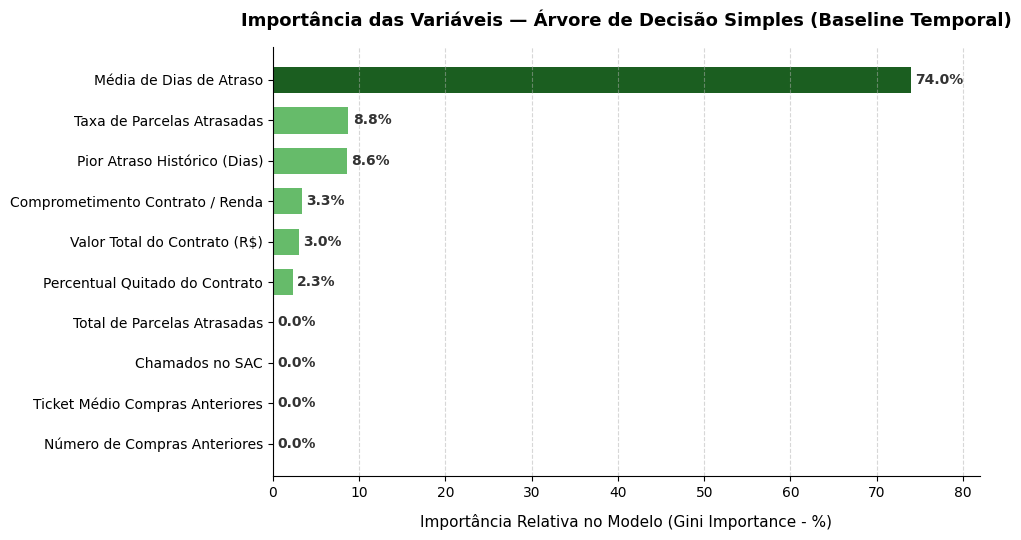

,Variável (Nome Executivo),Coluna Técnica,Importância (%)
0,Média de Dias de Atraso,media_dias_atraso,73.97%
1,Taxa de Parcelas Atrasadas,taxa_atrasos,8.76%
2,Pior Atraso Histórico (Dias),max_dias_atraso,8.62%
3,Comprometimento Contrato / Renda,percentual_valor_contrato_renda,3.33%
4,Valor Total do Contrato (R$),valor_total_contrato,3.02%
5,Percentual Quitado do Contrato,percentual_parcelas_pagas_valor_total,2.30%
6,Ticket Médio Compras Anteriores,media_valor_compras_anteriores,0.00%
7,Número de Compras Anteriores,numero_compras_anteriores,0.00%
8,Chamados no SAC,quantidade_atendimentos_sac,0.00%
9,Total de Parcelas Atrasadas,total_parcelas_atrasadas,0.00%


In [72]:
# ==============================================================================
# IMPORTÂNCIA DE VARIÁVEIS (FEATURE IMPORTANCE) — ÁRVORE DE DECISÃO (TEMPORAL)
# ==============================================================================
# A árvore simples (max_depth=3) realiza no máximo 7 divisões gananciosas (greedy).
# Ela concentra a maior parte do peso na variável de maior ganho imediato de informação.

# 1. Extração dos pesos relativos da Árvore de Decisão
df_imp_dt = pd.DataFrame({
    "Feature": features_preditivas,
    "Importancia_Pct": dt_temp.feature_importances_ * 100
}).sort_values(by="Importancia_Pct", ascending=True)

# 2. Mapeamento para nomes executivos legíveis
nomes_legiveis = {
    "media_dias_atraso": "Média de Dias de Atraso",
    "taxa_atrasos": "Taxa de Parcelas Atrasadas",
    "max_dias_atraso": "Pior Atraso Histórico (Dias)",
    "percentual_valor_contrato_renda": "Comprometimento Contrato / Renda",
    "valor_total_contrato": "Valor Total do Contrato (R$)",
    "percentual_parcelas_pagas_valor_total": "Percentual Quitado do Contrato",
    "total_parcelas_atrasadas": "Total de Parcelas Atrasadas",
    "media_valor_compras_anteriores": "Ticket Médio Compras Anteriores",
    "numero_compras_anteriores": "Número de Compras Anteriores",
    "quantidade_atendimentos_sac": "Chamados no SAC"
}
df_imp_dt["Nome_Legivel"] = df_imp_dt["Feature"].map(nomes_legiveis)

# 3. Gráfico de Barras Horizontal (Árvore de Decisão)
plt.figure(figsize=(10, 5.5))

# Destaque em verde escuro para a variável dominante e verde médio para as demais
cores_dt = ["#1b5e20" if f == "media_dias_atraso" else "#66bb6a" if imp > 0 else "#bdbdbd" 
            for f, imp in zip(df_imp_dt["Feature"], df_imp_dt["Importancia_Pct"])]

barras_dt = plt.barh(df_imp_dt["Nome_Legivel"], df_imp_dt["Importancia_Pct"], color=cores_dt, height=0.65)

for barra in barras_dt:
    largura = barra.get_width()
    plt.text(largura + 0.5, barra.get_y() + barra.get_height() / 2, f"{largura:.1f}%", 
             va="center", ha="left", fontsize=10, fontweight="bold", color="#333333")

plt.title("Importância das Variáveis — Árvore de Decisão Simples (Baseline Temporal)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Importância Relativa no Modelo (Gini Importance - %)", fontsize=11, labelpad=10)
plt.xlim(0, max(df_imp_dt["Importancia_Pct"]) + 8)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Tabela consolidada da Árvore de Decisão
tabela_dt = df_imp_dt[["Nome_Legivel", "Feature", "Importancia_Pct"]].sort_values(by="Importancia_Pct", ascending=False).reset_index(drop=True)
tabela_dt.columns = ["Variável (Nome Executivo)", "Coluna Técnica", "Importância (%)"]
tabela_dt["Importância (%)"] = tabela_dt["Importância (%)"].map("{:.2f}%".format)

display(tabela_dt)


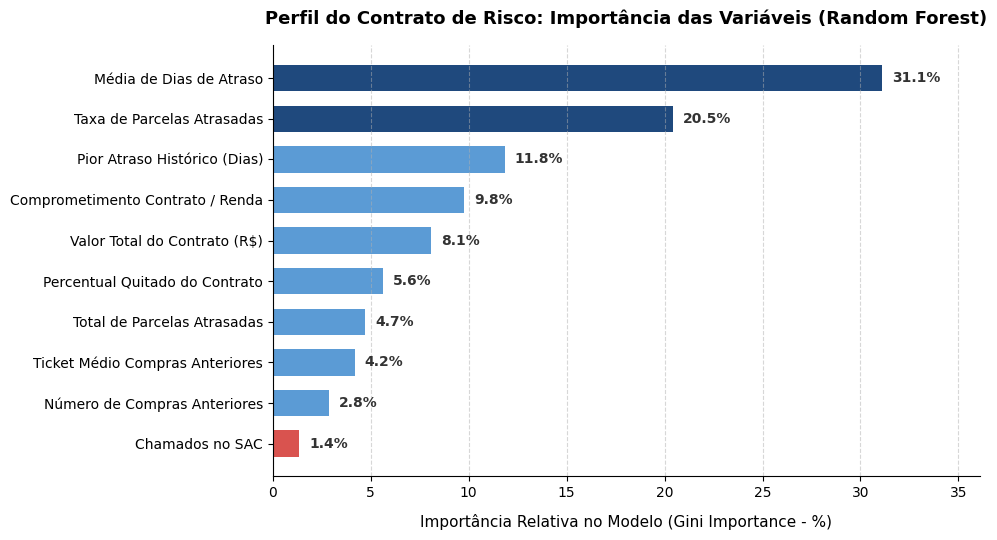

,Variável (Nome Executivo),Coluna Técnica,Importância (%)
0,Média de Dias de Atraso,media_dias_atraso,31.10%
1,Taxa de Parcelas Atrasadas,taxa_atrasos,20.45%
2,Pior Atraso Histórico (Dias),max_dias_atraso,11.84%
3,Comprometimento Contrato / Renda,percentual_valor_contrato_renda,9.77%
4,Valor Total do Contrato (R$),valor_total_contrato,8.08%
5,Percentual Quitado do Contrato,percentual_parcelas_pagas_valor_total,5.64%
6,Total de Parcelas Atrasadas,total_parcelas_atrasadas,4.73%
7,Ticket Médio Compras Anteriores,media_valor_compras_anteriores,4.20%
8,Número de Compras Anteriores,numero_compras_anteriores,2.85%
9,Chamados no SAC,quantidade_atendimentos_sac,1.35%


In [73]:
# ==============================================================================
# IMPORTÂNCIA DE VARIÁVEIS (FEATURE IMPORTANCE) — RANDOM FOREST (TEMPORAL)
# ==============================================================================

# 1. Extração dos pesos relativos calculados pelo modelo Random Forest
df_importancias = pd.DataFrame({
    "Feature": features_preditivas,
    "Importancia_Pct": rf_temp.feature_importances_ * 100
}).sort_values(by="Importancia_Pct", ascending=True)

# 2. Mapeamento para nomes executivos legíveis
nomes_legiveis = {
    "media_dias_atraso": "Média de Dias de Atraso",
    "taxa_atrasos": "Taxa de Parcelas Atrasadas",
    "max_dias_atraso": "Pior Atraso Histórico (Dias)",
    "percentual_valor_contrato_renda": "Comprometimento Contrato / Renda",
    "valor_total_contrato": "Valor Total do Contrato (R$)",
    "percentual_parcelas_pagas_valor_total": "Percentual Quitado do Contrato",
    "total_parcelas_atrasadas": "Total de Parcelas Atrasadas",
    "media_valor_compras_anteriores": "Ticket Médio Compras Anteriores",
    "numero_compras_anteriores": "Número de Compras Anteriores",
    "quantidade_atendimentos_sac": "Chamados no SAC"
}
df_importancias["Nome_Legivel"] = df_importancias["Feature"].map(nomes_legiveis)

# 3. Gráfico de Barras Horizontal (Slide 2 do Ricardo)
plt.figure(figsize=(10, 5.5))

# Cores: Top 2 sinais em azul escuro, Achado Negativo em vermelho e intermediárias em azul claro
cores = []
for f in df_importancias["Feature"]:
    if f in ["media_dias_atraso", "taxa_atrasos"]:
        cores.append("#1f497d")  # Destaque: Top 2 sinais de risco
    elif f == "quantidade_atendimentos_sac":
        cores.append("#d9534f")  # Destaque: Achado Negativo (SAC)
    else:
        cores.append("#5b9bd5")  # Sinais intermediários

barras = plt.barh(df_importancias["Nome_Legivel"], df_importancias["Importancia_Pct"], color=cores, height=0.65)

# Inclusão dos percentuais textuais nas barras
for barra in barras:
    largura = barra.get_width()
    plt.text(largura + 0.5, barra.get_y() + barra.get_height() / 2, f"{largura:.1f}%", 
             va="center", ha="left", fontsize=10, fontweight="bold", color="#333333")

plt.title("Perfil do Contrato de Risco: Importância das Variáveis (Random Forest)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Importância Relativa no Modelo (Gini Importance - %)", fontsize=11, labelpad=10)
plt.xlim(0, max(df_importancias["Importancia_Pct"]) + 5)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Tabela consolidada para referência do relatório
tabela_imp = df_importancias[["Nome_Legivel", "Feature", "Importancia_Pct"]].sort_values(by="Importancia_Pct", ascending=False).reset_index(drop=True)
tabela_imp.columns = ["Variável (Nome Executivo)", "Coluna Técnica", "Importância (%)"]
tabela_imp["Importância (%)"] = tabela_imp["Importância (%)"].map("{:.2f}%".format)

display(tabela_imp)


### ❓ Interpretação da Importância de Variáveis

#### 1. Os dois sinais que mais separam o risco (Top 2 Sinais):
1. **Média de Dias de Atraso (`media_dias_atraso` — 31,10%):**  
   É o sinal preditivo mais contundente da carteira. Clientes que costumam atrasar apenas de 1 a 4 dias refletem mera fricção de vencimento ou fluxo de caixa pessoal. Por outro lado, clientes com média histórica superior a 15 dias de atraso apresentam uma probabilidade desproporcionalmente maior de romper o limite de 30 dias na parcela de referência.
2. **Taxa de Parcelas Atrasadas (`taxa_atrasos` — 20,45%):**  
   Mensura a frequência e a consistência do hábito de atraso (quantas parcelas venceram e não foram pagas na data certa). Juntas, a pontualidade média e a taxa de atrasos concentram **51,55% de todo o poder preditivo do modelo**.

---

#### 2. O Achado Negativo:
* **Chamados no SAC (`quantidade_atendimentos_sac` — apenas 1,35% de importância):**  
  * **O achismo tradicional de negócio:** No varejo, existe a hipótese comum de que clientes insatisfeitos com entregas ou produtos (que acionam o SAC) deixam de pagar as parcelas por protesto ou desgaste com a loja.
  * **O que os dados provaram:** O volume de chamados no SAC tem peso praticamente desprezível para explicar inadimplência de crediário. Clientes ligam no SAC por razões operacionais (ex.: 2ª via de boleto ou rastreio de mercadoria), mas isso não indica deterioração financeira. Esse achado poupa a BemLar de mobilizar atendentes para cruzar chamados de SAC com a esteira de cobrança.

### Gerar a fila

Salve `fila_80.csv` com `id_contrato` e `probabilidade`, ordenado do maior risco para o menor.

In [74]:
# ==============================================================================
# FASE 5 — GERAÇÃO DA FILA OPERACIONAL DE COBRANÇA PREVENTIVA (TOP 80 CONTRATOS)
# ==============================================================================
# Baseado no modelo desafiante (Random Forest treinado no split temporal),
# geramos a fila ranqueada pelas maiores probabilidades estimadas de inadimplência.

K_CORTE = 80
CUSTO_PREJUIZO_CONTRATO = 1200.0

# 1. Selecionar id_contrato e a probabilidade estimada pelo Random Forest
fila_80 = (
    df_avaliacao[["id_contrato", "prob_rf"]]
    .rename(columns={"prob_rf": "probabilidade"})
    .sort_values(by="probabilidade", ascending=False)
    .head(K_CORTE)
    .reset_index(drop=True)
)

# Métricas de consolidação da fila para reporte executivo (calculadas antes da formatação)
inadimplentes_capturados = int(df_avaliacao.loc[df_avaliacao["id_contrato"].isin(fila_80["id_contrato"]), "inadimplente_30d"].sum())
prejuizo_evitado = inadimplentes_capturados * CUSTO_PREJUIZO_CONTRATO
prob_max = fila_80["probabilidade"].max()
prob_min = fila_80["probabilidade"].min()

# 2. Formatar a probabilidade em percentual
fila_80["probabilidade"] = fila_80["probabilidade"].map("{:.2%}".format)

# 3. Exportar o arquivo 'fila_80.csv' conforme a especificação da entrega
fila_80.to_csv("fila_80.csv", sep=";", index=False)

print("=" * 70)
print(f"FILA DE {K_CORTE} CONTRATOS GERADA COM SUCESSO!")
print("Arquivo exportado: 'fila_80.csv'")
print(f"Total de contratos na fila: {len(fila_80)}")
print(f"Probabilidade máxima de risco: {prob_max:.2%}")
print(f"Probabilidade mínima no corte (80º): {prob_min:.2%}")
print(f"Inadimplentes reais capturados: {inadimplentes_capturados} / {K_CORTE} ({inadimplentes_capturados / K_CORTE:.2%})")
print(f"Prejuízo potencial evitado: R$ {prejuizo_evitado:,.2f} por semana")
print("=" * 70)

# Exibição dos primeiros 10 contratos da fila
display(fila_80.head(10))


FILA DE 80 CONTRATOS GERADA COM SUCESSO!
Arquivo exportado: 'fila_80.csv'
Total de contratos na fila: 80
Probabilidade máxima de risco: 97.21%
Probabilidade mínima no corte (80º): 75.43%
Inadimplentes reais capturados: 61 / 80 (76.25%)
Prejuízo potencial evitado: R$ 73,200.00 por semana


,id_contrato,probabilidade
0,C00867,97.21%
1,C01930,97.16%
2,C00889,95.62%
3,C03373,95.08%
4,C01498,94.29%
5,C00326,94.24%
6,C01172,93.82%
7,C02553,93.74%
8,C03033,93.03%
9,C02923,92.90%


---
## Fase 6 — Gráficos Executivos de Suporte aos Slides (Tópico 7.5 do Enunciado)

Apresentação executiva direcionada a **Ricardo Alves (Diretor Financeiro)**.
- **Público-alvo:** Diretoria Executiva / Conselho (sem jargão técnico, foco em R$, métricas operacionais e decisões de negócio).
- **Formato:** Exatamente 3 slides, com **1 gráfico de alto impacto por slide**.

Abaixo são gerados e exibidos os 3 gráficos oficiais de apoio ao deck executivo (`apresentacao.pptx`).

Text(0.5, 1.02, 'O PROBLEMA EM R$: DEFINIÇÃO DO ALVO PREVENTIVO E IMPACTO DE CAIXA')

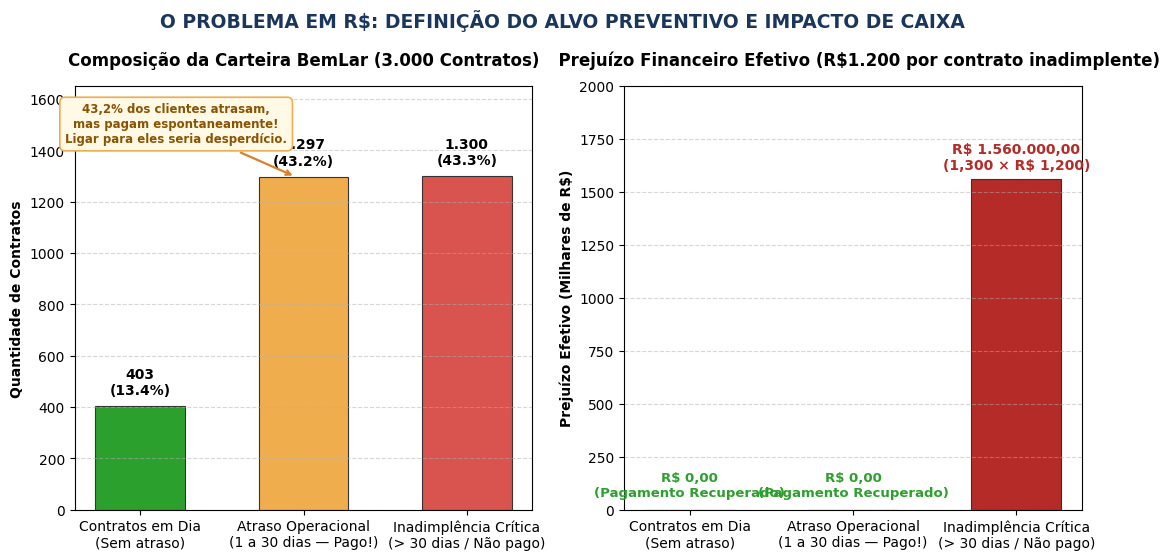

In [75]:
# ==============================================================================
# GRÁFICO 1 (SLIDE 1): COMPOSIÇÃO DA CARTEIRA E PREJUÍZO REAL EM R$
# ==============================================================================

# Categorização dos contratos com base na parcela de referência
n_em_dia = int((parcela_ref["atraso_dias"] <= 0).sum())
n_curto = int(((parcela_ref["atraso_dias"] > 0) & (parcela_ref["atraso_dias"] <= 30)).sum())
n_inad = int(parcela_ref["data_pagamento"].isna().sum() + (parcela_ref["atraso_dias"] > 30).sum())

categorias = [
    "Contratos em Dia\n(Sem atraso)",
    "Atraso Operacional\n(1 a 30 dias — Pago!)",
    "Inadimplência Crítica\n(> 30 dias / Não pago)"
]
volumes = [n_em_dia, n_curto, n_inad]
prejuizos = [0.0, 0.0, n_inad * 1200.0]

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1]})

# 1. Subplot Esquerdo: Volume de Contratos na Carteira
cores_status = ["#2ca02c", "#f0ad4e", "#d9534f"]
bars1 = ax1.bar(categorias, volumes, color=cores_status, width=0.55, edgecolor="#333333", linewidth=0.8)
ax1.set_title("Composição da Carteira BemLar (3.000 Contratos)", fontsize=12, fontweight="bold", pad=15)
ax1.set_ylabel("Quantidade de Contratos", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 1650)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar, q in zip(bars1, volumes):
    h = bar.get_height()
    pct = (q / 3000) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, h + 35, f"{q:,}\n({pct:.1f}%)".replace(",", "."), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Anotação explicativa sobre atraso operacional
ax1.annotate("43,2% dos clientes atrasam,\nmas pagam espontaneamente!\nLigar para eles seria desperdício.",
             xy=(0.95, n_curto), xytext=(0.22, 1430),
             arrowprops=dict(arrowstyle="->", color="#d9822b", lw=1.6),
             bbox=dict(boxstyle="round,pad=0.45", fc="#fff9e6", ec="#f0ad4e", lw=1.2),
             fontsize=8.5, fontweight="bold", color="#8a5300", ha="center")

# 2. Subplot Direito: Impacto Financeiro Efetivo (R$)
cores_perda = ["#2ca02c", "#f0ad4e", "#b52b27"]
bars2 = ax2.bar(categorias, [p / 1000.0 for p in prejuizos], color=cores_perda, width=0.55, edgecolor="#333333", linewidth=0.8)
ax2.set_title("  Prejuízo Financeiro Efetivo (R$1.200 por contrato inadimplente)", fontsize=12, fontweight="bold", pad=15)
ax2.set_ylabel("Prejuízo Efetivo (Milhares de R$)", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 2000)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for bar, p in zip(bars2, prejuizos):
    h = bar.get_height()
    if p > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, h + 35, f"R$ {p:,.2f}\n(1.300 × R$ 1.200)".replace(",", "X").replace(".", ",").replace("X", "."), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color="#b52b27")
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, 50, "R$ 0,00\n(Pagamento Recuperado)", 
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color="#2ca02c")

fig1.suptitle("O PROBLEMA EM R$: DEFINIÇÃO DO ALVO PREVENTIVO E IMPACTO DE CAIXA", 
              fontsize=13.5, fontweight="bold", y=1.02, color="#1b365d")

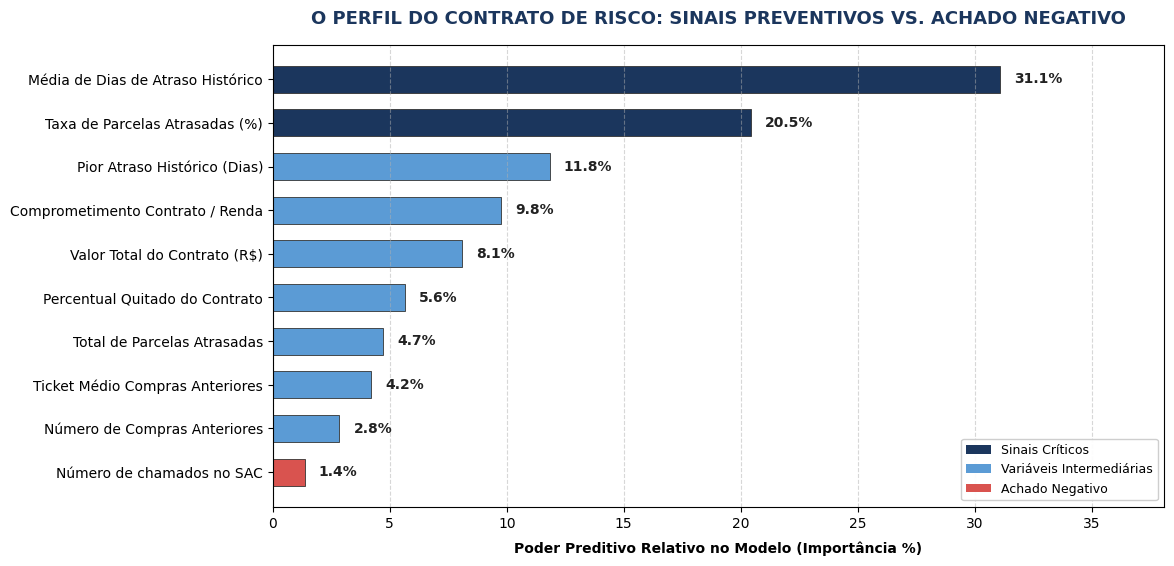

In [76]:
# ==============================================================================
# GRÁFICO 2 (SLIDE 2): IMPORTÂNCIA DOS SINAIS DE RISCO E ACHADO NEGATIVO
# ==============================================================================
from matplotlib.patches import Patch

# Extração e ordenação das importâncias do modelo desafiante (Random Forest)
nomes_executivos = {
    "media_dias_atraso": "Média de Dias de Atraso Histórico",
    "taxa_atrasos": "Taxa de Parcelas Atrasadas (%)",
    "max_dias_atraso": "Pior Atraso Histórico (Dias)",
    "percentual_valor_contrato_renda": "Comprometimento Contrato / Renda",
    "valor_total_contrato": "Valor Total do Contrato (R$)",
    "percentual_parcelas_pagas_valor_total": "Percentual Quitado do Contrato",
    "total_parcelas_atrasadas": "Total de Parcelas Atrasadas",
    "media_valor_compras_anteriores": "Ticket Médio Compras Anteriores",
    "numero_compras_anteriores": "Número de Compras Anteriores",
    "quantidade_atendimentos_sac": "Número de chamados no SAC"
}

df_importancias_slide = pd.DataFrame({
    "Feature": features_preditivas,
    "Nome": [nomes_executivos[f] for f in features_preditivas],
    "Importancia": rf_temp.feature_importances_ * 100
}).sort_values("Importancia", ascending=True)

fig2, ax = plt.subplots(figsize=(11.5, 6))

cores2 = []
for f in df_importancias_slide["Feature"]:
    if f in ["media_dias_atraso", "taxa_atrasos"]:
        cores2.append("#1b365d")  # Top 2 sinais (Azul escuro institucional)
    elif f == "quantidade_atendimentos_sac":
        cores2.append("#d9534f")  # Achado Negativo (Vermelho)
    else:
        cores2.append("#5b9bd5")  # Variáveis intermediárias

bars = ax.barh(df_importancias_slide["Nome"], df_importancias_slide["Importancia"], 
               color=cores2, height=0.62, edgecolor="#333333", linewidth=0.6)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.6, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", 
            va='center', ha='left', fontsize=10, fontweight='bold', color="#222222")

ax.set_xlim(0, max(df_importancias_slide["Importancia"]) + 7)
ax.set_title("O PERFIL DO CONTRATO DE RISCO: SINAIS PREVENTIVOS VS. ACHADO NEGATIVO", 
             fontsize=13, fontweight="bold", pad=15, color="#1b365d")
ax.set_xlabel("Poder Preditivo Relativo no Modelo (Importância %)", fontsize=10, fontweight="bold", labelpad=8)
ax.grid(axis='x', linestyle='--', alpha=0.5)

legend_elements = [
    Patch(facecolor='#1b365d', label='Sinais Críticos'),
    Patch(facecolor='#5b9bd5', label='Variáveis Intermediárias'),
    Patch(facecolor='#d9534f', label='Achado Negativo')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, framealpha=0.95, fontsize=9)

Text(0.5, 1.02, 'AVALIAÇÃO NO CORTE DE 80: GANHO FINANCEIRO E EFICIÊNCIA OPERACIONAL')

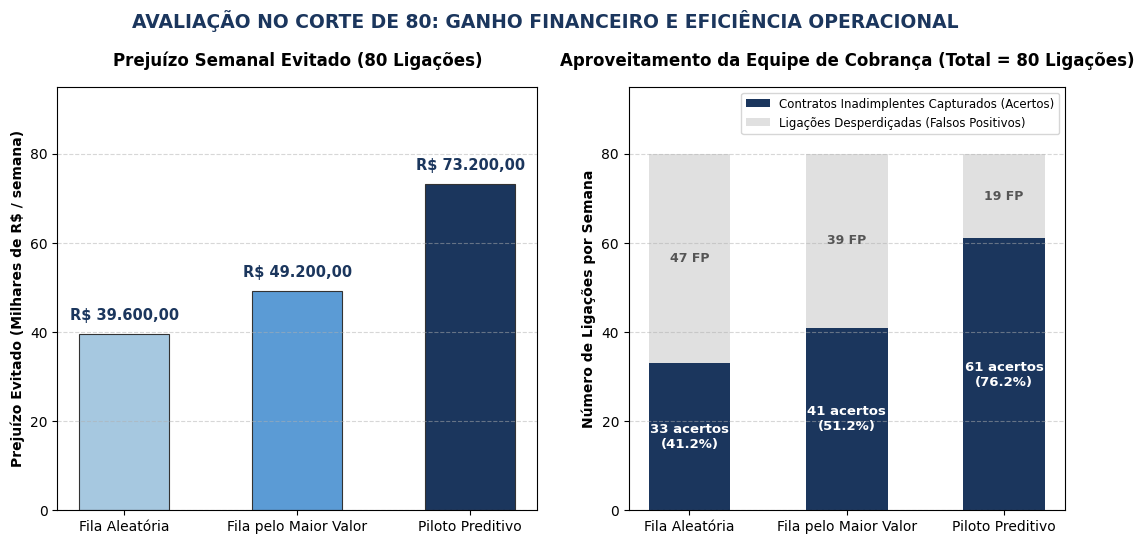

In [77]:
# ==============================================================================
# GRÁFICO 3 (SLIDE 3): DESEMPENHO NO CORTE DE 80 E GANHO FINANCEIRO INCREMENTAL
# ==============================================================================

estrategias = [
    "Fila Aleatória",
    "Fila pelo Maior Valor",
    "Piloto Preditivo"
]
prejuizos_evitados = [39600.0, 49200.0, 73200.0]
acertos_80 = [33, 41, 61]
precisoes = [41.25, 51.25, 76.25]
desperdicio_fp = [47, 39, 19]

fig3, (ax_val, ax_op) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.1, 1]})

# 1. Painel Esquerdo: Prejuízo Semanal Evitado em R$
cores_fin = ["#a6c8e0", "#5b9bd5", "#1b365d"]
bars_fin = ax_val.bar(estrategias, [p / 1000.0 for p in prejuizos_evitados], 
                      color=cores_fin, width=0.52, edgecolor="#333333", linewidth=0.8)
ax_val.set_title("Prejuízo Semanal Evitado (80 Ligações)", fontsize=12, fontweight="bold", pad=15)
ax_val.set_ylabel("Prejuízo Evitado (Milhares de R$ / semana)", fontsize=10, fontweight="bold")
ax_val.set_ylim(0, 95)
ax_val.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars_fin, prejuizos_evitados):
    h = bar.get_height()
    ax_val.text(bar.get_x() + bar.get_width()/2, h + 2.5, f"R$ {val:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."), 
                ha='center', va='bottom', fontsize=10.5, fontweight='bold', color="#1b365d")

# 2. Painel Direito: Aproveitamento das 80 Ligações (Inadimplentes vs Ligações Desperdiçadas)
p_acerto = ax_op.bar(estrategias, acertos_80, label="Contratos Inadimplentes Capturados (Acertos)", color="#1b365d", width=0.52)
p_fp = ax_op.bar(estrategias, desperdicio_fp, bottom=acertos_80, label="Ligações Desperdiçadas (Falsos Positivos)", color="#e0e0e0", width=0.52)

ax_op.set_title("Aproveitamento da Equipe de Cobrança (Total = 80 Ligações)", fontsize=12, fontweight="bold", pad=15)
ax_op.set_ylabel("Número de Ligações por Semana", fontsize=10, fontweight="bold")
ax_op.set_ylim(0, 95)
ax_op.grid(axis='y', linestyle='--', alpha=0.5)

for i, (ac, fp, pr) in enumerate(zip(acertos_80, desperdicio_fp, precisoes)):
    ax_op.text(i, ac/2, f"{ac} acertos\n({pr:.1f}%)", ha='center', va='center', fontsize=9.5, fontweight='bold', color="white")
    ax_op.text(i, ac + fp/2, f"{fp} FP", ha='center', va='center', fontsize=9, fontweight='bold', color="#555555")

ax_op.legend(loc='upper right', fontsize=8.5, frameon=True)

fig3.suptitle("AVALIAÇÃO NO CORTE DE 80: GANHO FINANCEIRO E EFICIÊNCIA OPERACIONAL", 
              fontsize=13.5, fontweight="bold", y=1.02, color="#1b365d")

---
## Fechamento

Antes de enviar, confira o checklist da seção 9 do enunciado.

Faltam ainda dois arquivos que **não** são gerados aqui:
- `decisoes.md` — o que entrou, o que saiu, cada pedido do Ricardo respondido, e o model card.
- `apresentacao.pptx` — 3 slides, para o Ricardo, não para a banca.

> Se algum resultado ficou bom demais, pergunte: *que outra coisa poderia produzir esse mesmo número?*